# **Clinical Trial Success Prediction: Strategic Benchmark & Validation Audit**

This notebook serves as the **Clinical Validation Sandbox**.

#### <REF:ENV_CONFIG>
> #### **1. Development Environment Configuration**

To ensure a seamless development workflow, we configure dynamic module reloading and precision-focused warning filters. This allows for iterative refinement of the `src` modules without requiring kernel restarts.

In [1]:
# <REF:ENV_CONFIG_CODE>
# --- AUTO-RELOAD MAGIC COMMANDS ---
%load_ext autoreload
%autoreload 2

import warnings
# 1. Initialize TQDM for Pandas (Enables progress_apply)
from tqdm.auto import tqdm
tqdm.pandas()

# 2. Silence Warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# <REF:/ENV_CONFIG_CODE>

#### <REF:PATH_RESOLUTION>
> #### **2. Project Path Resolution and Dynamic Imports**

*   **Dynamic Root Detection:** Implements a filesystem traversal algorithm to automatically locate the project root by searching for the `src` directory, ensuring portability across different environments (local vs. cloud).
*   **Environment Path Augmentation:** Appends the identified root directory to the system’s `PYTHONPATH`, enabling the usage of absolute imports (e.g., `import src.etl`) regardless of the notebook's location.
*   **Directory Standardization:** Defines and verifies global path constants (`DATA_PATH`, `MODELS_PATH`) to ensure consistent file I/O operations throughout the pipeline.

***

<REF:/PATH_RESOLUTION>

In [2]:
# <REF:PATH_RESOLUTION_CODE>
import sys
from pathlib import Path

# 1. Define the Project Root
# Start at the current directory and look for 'src' to identify the root
current_dir = Path.cwd()
project_root = current_dir

while not (project_root / 'src').exists():
    if project_root == project_root.parent:
        # Hit the filesystem root without finding the project
        raise FileNotFoundError("Could not find project root containing 'src'")
    project_root = project_root.parent

# 2. Add Project Root to System Path
# This allows 'import src...' to work from anywhere
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 3. Define Key Paths
DATA_PATH = project_root / "data"
MODELS_PATH = project_root / "models"

# 4. Verification
print(f"Project Root: {project_root}")
print(f"Data Path:    {DATA_PATH}")
print(f"Models Path:  {MODELS_PATH}")

# <REF:/PATH_RESOLUTION_CODE>

Project Root: /home/delaunan/code/delaunan/clintrialpredict
Data Path:    /home/delaunan/code/delaunan/clintrialpredict/data
Models Path:  /home/delaunan/code/delaunan/clintrialpredict/models


#### <REF:LIB_INIT>
> #### **3. Library and Custom Module Initialization**

*   **Analytical Framework Setup:** Imports the foundational Python libraries for structured data manipulation (`pandas`, `numpy`) and statistical visualization (`matplotlib`, `seaborn`).
*   **Domain-Specific Module Import:**
    *   Initializes the `ClinicalTrialLoader`: The custom ETL engine responsible for ingesting raw AACT data, enforcing inclusion criteria, and executing domain-specific feature engineering.
    *   Initializes the `preprocessor`: The pipeline factory that constructs the `ColumnTransformer` for rigorous feature scaling, encoding, and dimensionality reduction.

***

<REF:/LIB_INIT>

In [3]:
# <REF:LIB_INIT_CODE>
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom Modules/Closses
from src.prep.data_loader import ClinicalTrialLoader
from src.prep.preprocessing import preprocessor

# <REF:/LIB_INIT_CODE>

#### <REF:DATA_PIPELINE>
> #### **4.A Automated Data Pipeline & Workflow Integrity**

The pipeline executes a multi-stage ETL process to generate the analytical cohort. It includes a **Binary Workflow Decision** based on the availability of BioBERT embeddings. If embeddings are detected, the system locks the dataset for training; otherwise, it sanitizes text for external vectorization.

In [4]:
# <REF:DATA_PIPELINE_CODE>
# --- STEP 1: DATA LOADING & 'OFFLINE FEATURE STORE' CHECK ---
# We prioritize the 'project_data.csv' as our source of truth.
# If missing, we trigger the full ClinicalTrialLoader to rebuild the cohort from raw AACT files.

PROJECT_DATA_PATH = os.path.join(DATA_PATH, "project_data.csv")

if os.path.exists(PROJECT_DATA_PATH):
    df = pd.read_csv(PROJECT_DATA_PATH, low_memory=False)
    print(">>> Loaded existing project_data.csv")
    print(f"    Shape: {df.shape}")
else:
    print(">>> project_data.csv not found. Initializing full ingestion pipeline...")

    loader = ClinicalTrialLoader(str(DATA_PATH))

    # Cohort Generation: Industry Phase 2/3 trials with valid target status
    df = loader.load_and_clean()

    # Feature Enrichment: Tabular features + conditional BioBERT merge
    df = loader.add_features(df)

    # Persistence Logic: Exports 'light' version for GPU processing if vectors are missing
    loader.check_and_export_nlp(df)

    print(f"\n>>> Data Loaded. Final Shape: {df.shape}")

    # Verify text vectorization status
    cols_emb = [c for c in df.columns if c.startswith('crit_')]
    if cols_emb:
        print(f"    [STATUS] TRAINING READY. Detected {len(cols_emb)} NLP dimensions.")
    else:
        print(f"    [STATUS] PREP MODE. Embeddings missing.")

# <REF:/DATA_PIPELINE_CODE>

>>> Loaded existing project_data.csv
    Shape: (34155, 2362)


#### <REF:DATA_AUDIT>
> #### **4.B Forensic Data Audit: Integrity & Schema Verification**

Before modeling, we execute a forensic audit to ensure dataset completeness. This phase checks for row loss during CSV parsing, enforces critical numeric types, and verifies the density of the NLP feature store.

In [5]:
# <REF:DATA_AUDIT_CODE>
import pandas as pd
import numpy as np
import os
import sys

# --- CONFIGURATION ---
FILE_PATH = DATA_PATH / "project_data.csv"

def audit_data_integrity():
    print("="*100)
    print(f"FORENSIC DATA AUDIT: {os.path.basename(FILE_PATH)}")
    print("="*100)

    if not os.path.exists(FILE_PATH):
        print(f"[CRITICAL] File not found at: {FILE_PATH}")
        return

    # --------------------------------------------------------------------------
    # 1. THE "SKIPPED LINE" CHECK (Raw vs Parsed)
    # --------------------------------------------------------------------------
    print(">>> Phase 1: Integrity Check (Did we lose rows?)")

    # Count raw lines in file (fast generator, low memory)
    with open(FILE_PATH, 'rb') as f:
        raw_line_count = sum(1 for _ in f)

    # Load DataFrame
    df = pd.read_csv(FILE_PATH, low_memory=False)
    df_rows = len(df)

    # Logic: Raw Lines = Header (1) + Data Rows
    expected_rows = raw_line_count - 1
    diff = expected_rows - df_rows

    print(f"    Raw File Lines:      {raw_line_count:,}")
    print(f"    DataFrame Rows:      {df_rows:,}")

    if diff == 0:
        print("    [PASS] Perfect Match. No lines skipped.")
    elif diff > 0:
        print(f"    [WARN] Discrepancy: {diff} fewer rows in DataFrame than in file.")
        print("           (This can happen if some text fields contain newlines within quotes).")
    else:
        print(f"    [WTF?] DataFrame has MORE rows than file lines. Check parsing engine.")

    # --------------------------------------------------------------------------
    # 2. CRITICAL COLUMN TYPE CHECK
    # --------------------------------------------------------------------------
    print("\n>>> Phase 2: Critical Type Enforcement")

    critical_checks = {
        'start_year': [np.integer, np.floating], # Must be numeric
        'target':     [np.integer, np.floating], # Must be numeric
        'nct_id':     [object, str]              # Must be string
    }

    for col, valid_types in critical_checks.items():
        if col not in df.columns:
            print(f"    [FAIL] Missing Column: {col}")
            continue

        actual_type = df[col].dtype
        is_valid = any(np.issubdtype(actual_type, t) for t in valid_types)

        # Pandas often reports 'int64' which is a subdtype of np.integer
        # If strict numpy check fails, try pandas api
        if not is_valid:
            if col == 'start_year' and pd.api.types.is_numeric_dtype(df[col]):
                is_valid = True
            if col == 'nct_id' and pd.api.types.is_string_dtype(df[col]):
                is_valid = True

        status = "[PASS]" if is_valid else "[FAIL]"
        print(f"    {status} {col:<15} | Type: {actual_type}")

    # --------------------------------------------------------------------------
    # 3. EMBEDDING PRESENCE CHECK
    # --------------------------------------------------------------------------
    print("\n>>> Phase 3: Feature Store Content")

    emb_cols = [c for c in df.columns if c.startswith('crit_')]
    if len(emb_cols) > 0:
        print(f"    [INFO] Embeddings Detected: {len(emb_cols)} dimensions found.")
        # Check for "Zero Vector" bug (if embeddings are all 0, something failed)
        sample_sum = df[emb_cols[0]].sum()
        if sample_sum == 0:
             print("    [FAIL] Embeddings appear to be all zeros!")
        else:
             print("    [PASS] Embeddings contain non-zero data.")
    else:
        print("    [WARN] No Embeddings found (Prep Mode).")

    # --------------------------------------------------------------------------
    # 4. DETAILED MISSING VALUE REPORT
    # --------------------------------------------------------------------------
    print("\n>>> Phase 4: Detailed Column Scan")
    print("-" * 100)
    print(f"{'COLUMN NAME':<35} | {'DTYPE':<10} | {'MISSING':<8} | {'%':<6} | {'SAMPLE VALUE'}")
    print("-" * 100)

    for col in df.columns:
        # Skip printing all 768 embedding columns to keep log readable
        if col.startswith(('crit_', 'sci_', 'endp_')) and col != 'crit_0':
            continue
        if col == 'crit_0':
            print(f"{'... [Embeddings Hidden] ...':<35} | {'float':<10} | {'0':<8} | {'0.0%':>4} | {'(Vectors)'}")
            continue

        dtype = str(df[col].dtype)
        n_miss = df[col].isna().sum()
        pct_miss = (n_miss / len(df)) * 100

        # Get clean sample
        sample = df[col].dropna().iloc[0] if n_miss < len(df) else "ALL NAN"
        sample_str = str(sample)[:25]

        # Flags
        flag = ""
        if pct_miss > 0: flag = " [!]"
        if col == 'start_year' and not pd.api.types.is_numeric_dtype(df[col]): flag = " [TYPE ERROR]"

        print(f"{col:<35} | {dtype:<10} | {n_miss:<8} | {pct_miss:>4.1f}% | {sample_str:<25}{flag}")

    print("-" * 100)

if __name__ == "__main__":
    audit_data_integrity()


# <REF:/DATA_AUDIT_CODE>

FORENSIC DATA AUDIT: project_data.csv
>>> Phase 1: Integrity Check (Did we lose rows?)
    Raw File Lines:      34,156
    DataFrame Rows:      34,155
    [PASS] Perfect Match. No lines skipped.

>>> Phase 2: Critical Type Enforcement
    [PASS] start_year      | Type: float64
    [PASS] target          | Type: int64
    [PASS] nct_id          | Type: object

>>> Phase 3: Feature Store Content
    [INFO] Embeddings Detected: 768 dimensions found.
    [PASS] Embeddings contain non-zero data.

>>> Phase 4: Detailed Column Scan
----------------------------------------------------------------------------------------------------
COLUMN NAME                         | DTYPE      | MISSING  | %      | SAMPLE VALUE
----------------------------------------------------------------------------------------------------
nct_id                              | object     | 0        |  0.0% | NCT00526188              
start_date                          | object     | 0        |  0.0% | 2007-08-31       

#### <REF:NLP_AUDIT>
> #### **5. Pre-Computation NLP Signal & Leakage Audit**

This audit scans text fields for 'Day Zero' violations (administrative keywords like 'updated' or NCT IDs) that could cause artificial performance inflation. It also validates the preservation of scientific nomenclature (e.g., RECIST, OS) to ensure the embedding model receives high-signal input.

In [6]:
# <REF:NLP_AUDIT_CODE>
import pandas as pd
import re

# Source for BioBERT processing
file_path = DATA_PATH / "data_clinpred_emb_transform.csv"

if not file_path.exists():
    print(f"[!] Audit Skip: {file_path.name} not found.")
else:
    df_audit = pd.read_csv(file_path)

    print("="*80); print(f"FINAL NLP DATASET AUDIT: {file_path.name}"); print("="*80)

    # --- INTEGRITY: Ensuring no blank pillars ---
    nulls = df_audit.isna().sum().sum()
    print(f"[1] Integrity: Total Rows={len(df_audit)}, Missing Values={nulls}")

    # --- LEAKAGE: Searching for administrative updates that signal 'after-the-fact' data ---
    df_audit["txt_criteria"] = df_audit["txt_criteria"].astype(str)
    leakage_keywords = ["amendment", "protocol v", "version", "updated", "modified", "clinicaltrials.gov"]

    print("\n[2] Leakage Markers (Lower is better):")
    for word in leakage_keywords:
        count = df_audit["txt_criteria"].str.contains(re.escape(word), case=False).sum()
        print(f"  - '{word}': {count}")

    # --- SIGNAL: Validating clinical nomenclature retention ---
    print("\n[3] Scientific Signal Preservation:")
    protected = ["RECIST", "HbA1c", "ECOG", "NYHA", "mg/kg", "ORR", "OS"]
    for term in protected:
        count = df_audit["txt_criteria"].str.contains(re.escape(term), case=False).sum()
        print(f"  - '{term}': {count}")

    print("\n" + "="*80); print("AUDIT COMPLETE"); print("="*80)
# <REF:/NLP_AUDIT_CODE>

FINAL NLP DATASET AUDIT: data_clinpred_emb_transform.csv
[1] Integrity: Total Rows=34155, Missing Values=0

[2] Leakage Markers (Lower is better):
  - 'amendment': 66
  - 'protocol v': 78
  - 'version': 489
  - 'updated': 13
  - 'modified': 213
  - 'clinicaltrials.gov': 0

[3] Scientific Signal Preservation:
  - 'RECIST': 2119
  - 'HbA1c': 1868
  - 'ECOG': 4454
  - 'NYHA': 1864
  - 'mg/kg': 401
  - 'ORR': 4919
  - 'OS': 30698

AUDIT COMPLETE


#### <REF:TEMP_SPLIT>
> #### **6. Temporal Partitioning: The Golden Split**

To simulate a forward-looking deployment, we partition data by time. The **Training Set (2009–2020)** establishes historical patterns, while the **Blind Test Set (2021–2022)** measures the model's ability to predict trials that haven't happened yet in the training distribution.

In [7]:
# <REF:TEMP_SPLIT_CODE>
TRAIN_START_YEAR, TRAIN_END_YEAR = 2009, 2020
TEST_START_YEAR, TEST_END_YEAR = 2021, 2022

print('>>> Applying Temporal Split Strategy...')
mask_train = df['start_year'].between(TRAIN_START_YEAR, TRAIN_END_YEAR)
mask_test  = df['start_year'].between(TEST_START_YEAR, TEST_END_YEAR)

# Exclude non-predictive metadata and raw text from the training matrix
cols_meta = ['target', 'nct_id', 'start_date', 'start_year', 'official_title', 'why_stopped']
cols_text = [c for c in df.columns if c.startswith('txt_') ]
cols_to_drop = cols_meta + cols_text

# 1. Prepare Training (2009-2020)
df_train_temp = df.loc[mask_train].copy()
df_train_temp['start_date'] = pd.to_datetime(df_train_temp['start_date'], errors='coerce')
df_train_temp = df_train_temp.sort_values(by=['start_date', 'nct_id'])
X_train, y_train = df_train_temp.drop(columns=cols_to_drop, errors='ignore'), df_train_temp['target']

# 2. Prepare Testing (2021-2022)
df_test_temp = df.loc[mask_test].copy()
df_test_temp['start_date'] = pd.to_datetime(df_test_temp['start_date'], errors='coerce')
df_test_temp = df_test_temp.sort_values(by=['start_date', 'nct_id'])
X_test, y_test = df_test_temp.drop(columns=cols_to_drop, errors='ignore'), df_test_temp['target']

print(f'    Training Cohort: {X_train.shape[0]:,} trials')
print(f'    Blind Test Set:  {X_test.shape[0]:,} trials')
# <REF:/TEMP_SPLIT_CODE>

>>> Applying Temporal Split Strategy...
    Training Cohort: 21,604 trials
    Blind Test Set:  2,988 trials


#### <REF:MODEL_TRAIN>
> #### **7. Model Configuration: XGBoost with Class Balancing**

We utilize an XGBoost classifier with strict regularization (shallow trees, high alpha/lambda) to prioritize broad, generalizable patterns over noise. To handle the natural class imbalance (trials succeed more often than they fail), we calculate `scale_pos_weight`, forcing the model to pay more attention to the minority failure class.

In [8]:
# <REF:MODEL_TRAIN_CODE>
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from src.prep.preprocessing import preprocessor

print('\n=== STEP 7: TRAINING MODEL ===')

# Imbalance Handling: Ratio of Successes to Failures
n_pos = y_train.sum(); ratio = (len(y_train) - n_pos) / n_pos

xgb = XGBClassifier(
    n_estimators=495, learning_rate=0.02, max_depth=3,
    min_child_weight=25, gamma=10, subsample=0.728,
    colsample_bytree=0.30, reg_alpha=30, reg_lambda=30,
    scale_pos_weight=ratio, tree_method='hist', eval_metric='logloss',
    n_jobs=-1, random_state=42, enable_categorical=False
)

model = Pipeline([('prep', preprocessor()), ('clf', xgb)])

print('>>> Fitting Model Pipeline...')
model.fit(X_train, y_train)
print('    [DONE] Training complete.')
# <REF:/MODEL_TRAIN_CODE>


=== STEP 7: TRAINING MODEL ===
>>> Fitting Model Pipeline...
    [DONE] Training complete.


#### <REF:PRED_GEN>
> #### **8. Prediction Generation on Test set**

*   **Risk Scoring:** Computes the probability of trial termination (`y_prob`) for the test set, specifically isolating the score for the positive class (failure risk).
*   **Binary Classification:** Generates hard class labels (`y_pred`) using the standard decision threshold (0.5) to facilitate immediate performance evaluation.

***

<REF:/PRED_GEN>

In [9]:
# <REF:PRED_GEN_CODE>

# predict_proba gives [Prob_Success, Prob_Failure]. We want column 1 (Failure).
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# <REF:/PRED_GEN_CODE>

#### <REF:POLICY_OPT>
> #### **8.B Decision Policy Validation (Honesty Check)**

Before finalizing thresholds, we validate our chosen policy ($\beta = 0.70$, $N = 400$) on the **Modern Fold** (the last fold of the TimeSeriesSplit). This ensures that our philosophical preference for Precision (Reliability) results in a stable signal in the most recent historical era (2018–2020).

In [10]:
# <REF:POLICY_ANCHORS_CODE>
# --- GLOBAL STRATEGY KNOBS ---
F1_calibration = 1.15     # The 'Beta'. < 1.0 favors Precision, > 1.0 favors Recall.
min_samples_policy = 500   # Min trials needed for a TA to get its own threshold.
w_floor, w_ceil = 0.1, 1.0 # Recency Weighting: Oldest (0.3) to Newest (1.0).

In [11]:
def find_optimal_threshold(y_true, y_probs, beta=1.0, weights=None):
    """
    Finds threshold maximizing F-beta score.
    Optional 'weights' parameter allows for temporal recency bias.
    """
    import numpy as np
    from sklearn.metrics import precision_recall_curve

    # Weights impact the Precision/Recall points calculation
    p, r, t = precision_recall_curve(y_true, y_probs, sample_weight=weights)
    f = (1 + beta**2) * (p * r) / (beta**2 * p + r + 1e-9)

    return t[np.argmax(f[:-1])] if len(t) > 0 else 0.5

#### <REF:DYN_THRESH>
> #### **9. Unified Dynamic Threshold Calibration (Recency-Weighted In-Sample)**

This module implements **Granular Thresholding** using the full training cohort. It ensures decision boundaries are sensitive to the unique risk profiles of different Therapeutic Areas (TAs).

**The Recency-Weighted Logic:** To ensure the model is optimized for the modern clinical landscape, we apply temporal weights to the training data. Trials from the early era (2009) carry a lower weight (e.g., 0.1), while the most recent trials (2020) carry full weight (1.0). This forces the threshold optimization algorithm to prioritize contemporary success/failure patterns while still utilizing the full volume of historical data for stability. TAs with insufficient modern data default to the Global Pool Threshold to prevent noise-driven overfitting.

In [12]:
# <REF:DYN_THRESH_CODE>
import json
import pandas as pd
import numpy as np
from scipy.special import logit

print('=== STEP 9: RECENCY-WEIGHTED CALIBRATION (IN-SAMPLE) ===')
# --- SYNC LOGIC: Inheriting Knobs from Anchor Cell ---
print(f'>>> Policy: Beta={F1_calibration} | Recency Bias: {w_floor} to {w_ceil}')

# 1. GENERATE PREDICTIONS & DYNAMIC WEIGHTS
y_prob_train = model.predict_proba(X_train)[:, 1]
train_years = df.loc[X_train.index, 'start_year']
y_min, y_max = train_years.min(), train_years.max()

# --- SYNC LOGIC: Recency formula using global knobs ---
train_weights = w_floor + (w_ceil - w_floor) * (train_years - y_min) / (y_max - y_min)

df_cal = pd.DataFrame({
    'TA': X_train['therapeutic_area'],
    'true': y_train.values,
    'prob': y_prob_train,
    'weight': train_weights
})

# 2. CALCULATE WEIGHTED THRESHOLDS
global_thresh = find_optimal_threshold(df_cal['true'], df_cal['prob'], beta=F1_calibration, weights=df_cal['weight'])
# --- SYNC LOGIC: Logit Conversion for Step 7 ---
global_logit = float(logit(np.clip(global_thresh, 1e-5, 1-1e-5)))

print('')
print(f'🌍 Global Pool Threshold: {global_thresh:.4f} (Logit: {global_logit:.4f})')

final_thresholds = {}
final_threshold_logits = {}
audit_log = []
ta_counts = df_cal['TA'].value_counts()

for ta, count in ta_counts.items():
    df_ta = df_cal[df_cal['TA'] == ta]
    weighted_n = df_ta['weight'].sum() # Audit Impact of Recency Weights

    if count < min_samples_policy:
        final_thresholds[ta] = global_thresh
        final_threshold_logits[ta] = global_logit
        continue

    if len(df_ta['true'].unique()) <= 1:
        final_thresholds[ta] = global_thresh
        final_threshold_logits[ta] = global_logit
        continue

    t_ta = find_optimal_threshold(df_ta['true'], df_ta['prob'], beta=F1_calibration, weights=df_ta['weight'])
    t_ta_clipped = np.clip(t_ta, 1e-5, 1-1e-5)

    final_thresholds[ta] = t_ta
    final_threshold_logits[ta] = float(logit(t_ta_clipped))
    audit_log.append({'TA': ta, 'Raw_N': count, 'Eff_N': f"{weighted_n:.1f}", 'Threshold': t_ta})

# 3. SAVE ARTIFACTS
cal_arts = {
    'model_version': 'recency_weighted_v4_synced',
    'beta': F1_calibration,
    'recency_range': [w_floor, w_ceil],
    'global_threshold': float(global_thresh),
    'ta_thresholds': {ta: float(t) for ta, t in final_thresholds.items()},
    'ta_threshold_logits': final_threshold_logits
}
with open('calibration_granular_model_validation.json', 'w') as f: json.dump(cal_arts, f, indent=2)

print('')
print('--- CALIBRATION REPORT (WEIGHTED EFF_N) ---')
print(pd.DataFrame(audit_log).to_string(index=False))
print('')
print('✅ Logic Synced: Changes to Global Knobs will now be reflected in all charts.')
# <REF:/DYN_THRESH_CODE>

=== STEP 9: RECENCY-WEIGHTED CALIBRATION (IN-SAMPLE) ===
>>> Policy: Beta=1.15 | Recency Bias: 0.1 to 1.0

🌍 Global Pool Threshold: 0.5362 (Logit: 0.1449)

--- CALIBRATION REPORT (WEIGHTED EFF_N) ---
              TA  Raw_N  Eff_N  Threshold
        Oncology   4466 2429.3   0.605647
      Infections   2846 1524.4   0.473065
       Neurology   2174 1149.1   0.543624
       Metabolic   1462  713.6   0.410767
 Musculoskeletal   1295  649.8   0.494111
     Respiratory   1273  598.4   0.385573
Gastrointestinal   1216  677.8   0.529360
  Cardiovascular    912  439.2   0.495348
     Dermatology    858  488.9   0.403187
   Ophthalmology    840  465.8   0.517558
      Psychiatry    806  390.9   0.436196
   Renal/Urology    774  392.5   0.488982
      Hematology    639  364.0   0.556228
    Unclassified    524  269.4   0.478406

✅ Logic Synced: Changes to Global Knobs will now be reflected in all charts.


#### <REF:EXPLAIN_ENGINE>
> #### **10. Explainability Engine: SHAP-Based Feature Attribution**

To move beyond 'black-box' predictions, we utilize SHAP (SHapley Additive exPlanations) to decompose every prediction into its constituent drivers. This allows us to quantify the exact contribution of each protocol feature (e.g., duration, masking) to the final risk score, enabling actionable root-cause analysis for stakeholders.

In [13]:
# <REF:EXPLAIN_ENGINE_CODE>
import shap
import pandas as pd
import numpy as np

print("\n>>> STEP 10: CALCULATING SHAP VALUES (TEST SET)...")

# 1. Reconstruct Input Matrix: Reproduce the transformed data seen by the model
prep_step = model.named_steps['prep']
prep_step.verbose_feature_names_out = True
X_test_trans = prep_step.transform(X_test)
feature_names = prep_step.get_feature_names_out()

# 2. Attribution Calculation: Use TreeExplainer for exact mathematical decomposition
print("    [SHAP] Decomposing Test Set predictions...")
explainer = shap.TreeExplainer(model.named_steps['clf'])
shap_values = explainer.shap_values(X_test_trans)

# 3. Intercept Capture: The 'Expected Value' in log-odds space
model_base_value = explainer.expected_value
if isinstance(model_base_value, (list, np.ndarray)):
    model_base_value = model_base_value[0]

print(f"    [DONE] Matrix Shape: {shap_values.shape}")
print(f"    [Check] Intercept: {model_base_value:.4f}")
# <REF:/EXPLAIN_ENGINE_CODE>


>>> STEP 10: CALCULATING SHAP VALUES (TEST SET)...
    [SHAP] Decomposing Test Set predictions...
    [DONE] Matrix Shape: (2988, 548)
    [Check] Intercept: 0.0226


#### <REF:SCORE_ENGINE>
> #### **11. Clinical Scoring Engine: Logit-to-Integer Transformation**

The Scoring Engine transforms raw log-odds into a hierarchical **Clinical Success Score (0–100)**. 

**Strategic Anchoring:** A score of **50.0** always represents the exact decision boundary for that trial's Therapeutic Area. 

**Success Orientation:** Since the model predicts *failure* risk, we invert the signs so that positive contributions represent strengths that increase the final success score. 

**Full Accounting Logic:** To ensure perfect consistency between the **Gauge**, **Impact Bar Chart**, and **Treemap**, we calculate a `CALIBRATION_OFFSET`. This represents the mathematical gap between the model's global average (the Intercept) and the specific TA boundary. This offset is merged into the **"Therapeutic Context"** pillar, ensuring that the "starting line" of the disease area is correctly accounted for before protocol-specific impacts are added.

In [14]:
# <REF:SCORE_ENGINE_CODE>
import pandas as pd
import numpy as np
from scipy.special import logit

print("\n>>> STEP 11: SCORING ENGINE (SUCCESS-ORIENTED UI)...")

RISK_TAXONOMY = {
    "1. Therapeutic Context": {
        "Indication Risk Profile": {
            "features": [
                "cat_onehot__therapeutic_area_",
                "cat_target__therapeutic_subgroup_name",
                "CALIBRATION_OFFSET"
            ],
            "feature_labels": [
                "Net Disease Risk"
            ],
            "logic": "The combined risk profile of the therapeutic area and specific indication, adjusted for sector difficulty.",
            "pos_impact": "Therapeutic area and indication show a rather favorable risk profile based on historical evidence.",
            "neg_impact": "Therapeutic area and indication may correspond to elevated challenge levels given past records."
        },
        "Development Phase": {
            "features": [
                "cat_onehot__phase_PHASE",
                "cat_onehot__phase_group_"
            ],
            "feature_labels": [
                "Trial Phase",
                "Phase Tier"
            ],
            "logic": "The statistical probability of success (POS) based on development stage.",
            "pos_impact": "The current study stage is statistically associated with higher completion rates.",
            "neg_impact": "The current study stage is associated with higher attrition risks."
        }
    },
    "2. Scientific Design": {
        "Scientific Rationale": {
            "features": [
                "pca_sci"
            ],
            "feature_labels": [
                "Scientific Text Analysis"
            ],
            "logic": "Text analysis of the Title and Brief Summary for novelty and clarity.",
            "pos_impact": "Text analysis suggests the scientific rationale is clear, focused, and aligns with successful precedents.",
            "neg_impact": "Text analysis suggests the scientific description may be ambiguous, with lesser focus or highly novel, which tends to carry higher uncertainty."
        },
        "Endpoint Strategy": {
            "features": [
                "pca_endp"
            ],
            "feature_labels": [
                "Endpoint Text Analysis"
            ],
            "logic": "Text analysis of the Primary Endpoints for measurability.",
            "pos_impact": "Primary endpoints appear well-defined and measurable, consistent with previous successful trials.",
            "neg_impact": "Endpoints can be improved as they may appear complex or subjective, which tends to introduce measurement variability."
        },
        "Trial Complexity": {
            "features": [
                "num_log__number_of_arms",
                "cat_onehot__primary_purpose_"
            ],
            "feature_labels": [
                "Arm Count",
                "Primary Purpose"
            ],
            "logic": "Structural design of the study arms.",
            "pos_impact": "The structural design (number of arms and primary purpose) suggests a comprehensive comparative strategy.",
            "neg_impact": "The structural design (number of arms and primary purpose) suggests either a simplified exploratory focus or a level of complexity that may increase operational burden,"
        }
    },
    "3. Execution Framework": {
        "Quality & Bias Control": {
            "features": [
                "bin_flags__has_dmc",
                "num_std__design_rigor_score",
                "cat_onehot__masking_"
            ],
            "feature_labels": [
                "Data Monitoring Comm.",
                "Rigor Score",
                "Blinding"
            ],
            "logic": "Operational mechanisms implemented to minimize bias and ensure safety oversight.",
            "pos_impact": "Operational controls (e.g., DMC, masking) are in place to safeguard data integrity and reduce bias.",
            "neg_impact": "The protocol suggests limited bias mitigation or oversight mechanisms, increasing operational vulnerability."
        },
        "Time Horizon": {
            "features": [
                "num_log__duration_months"
            ],
            "feature_labels": [
                "Estimated Duration"
            ],
            "logic": "The operational exposure time of the study.",
            "pos_impact": "Shorter duration tends to minimize exposure to long-term operational risks.",
            "neg_impact": "Extended timeline tends to increase the risk of participant dropout and resource exhaustion."
        },
        "Sponsor Profile": {
            "features": [
                "cat_onehot__sponsor_tier_"
            ],
            "feature_labels": [
                "Sponsor Tier"
            ],
            "logic": "The track record and financial depth of the sponsor.",
            "pos_impact": "Sponsor profile suggests established resources, experience or operational resilience.",
            "neg_impact": "Sponsor profile may be sensitive to funding constraints or prone to frequent strategic portfolio shifts."
        }
    },
    "4. Patient Profile": {
        "Inclusion Criteria": {
            "features": [
                "pca_crit",
                "num_std__criteria_len_log",
                "num_std__eligibility_strictness_score"
            ],
            "feature_labels": [
                "Criteria Text Analysis",
                "Criteria Length",
                "Strictness Score"
            ],
            "logic": "Text analysis of the eligibility rules.",
            "pos_impact": "Eligibility criteria appear concise and balanced, facilitating smoother enrollment.",
            "neg_impact": "Lengthy or highly restrictive criteria tend to create enrollment bottlenecks."
        },
        "Patient Acuity": {
            "features": [
                "bin_flags__is_sick_only",
                "bin_flags__is_severe",
                "bin_flags__is_acute",
                "bin_flags__is_refractory",
                "bin_flags__is_critical_setting"
            ],
            "feature_labels": [
                "Healthy vs Patient",
                "Severe Disease",
                "Acute Setting",
                "Refractory Status",
                "Critical Setting Flag"
            ],
            "logic": "The health status of the target population.",
            "pos_impact": "Target population appears stable, potentially reducing unexpected medical complications.",
            "neg_impact": "Populations with high disease severity, acuity, or refractory status tend to be associated with elevated operational risks."
        }
    }
}

GAIN_FACTOR = 25.0 # Scales 1 logit unit to 25 UI points # Scales 1 logit unit to 25 UI points # Scales 1 logit unit to 25 UI points

def generate_clinical_scorecard(X_test, shap_values, feature_names, taxonomy,
                                base_value, thresholds_logit_map, global_thresh_logit, gain=GAIN_FACTOR):
    # --- 1. Pillar Aggregation ---
    feat_to_pillar = {}
    for i, feat in enumerate(feature_names):
        for pillar, topics in taxonomy.items():
            for topic, details in topics.items():
                if any(feat.startswith(prefix) for prefix in details['features']):
                    feat_to_pillar[i] = pillar

    pillar_shap_sums = pd.DataFrame(0.0, index=X_test.index, columns=taxonomy.keys())
    for i in range(shap_values.shape[1]):
        p = feat_to_pillar.get(i)
        if p: pillar_shap_sums[p] += shap_values[:, i]

    # --- 2. Normalized Success Scoring ---
    # --- SYNC LOGIC: Delta-Logit Success Formula ---
    # Decision Boundary (Logit Space)
    row_threshold_logits = X_test['therapeutic_area'].map(thresholds_logit_map).fillna(global_thresh_logit)

    # Model Probability (Logit Space)
    model_pred_logit = base_value + np.sum(shap_values, axis=1)

    # Success Potential = Boundary - Model_Risk
    delta_logit = row_threshold_logits - model_pred_logit
    scorecard = pd.DataFrame(index=X_test.index)
    scorecard['Clinical_Score'] = (50 + (delta_logit * gain)).clip(1, 99)

    # --- 3. Pillar Decomposition (Success-Oriented) ---
    # --- SYNC LOGIC: The Bridge Variable ---
    calibration_offset = row_threshold_logits - base_value
    for pillar in taxonomy.keys():
        scorecard[pillar] = pillar_shap_sums[pillar] * gain * -1 # Invert risk to success

        # STRATEGIC SYNC: Merge calibration offset into Therapeutic Context
    # This ensures that Score = 50 + Sum(Pillar Impacts) for UI consistency
    target_pillar = "1. Therapeutic Context"
    if target_pillar in scorecard.columns:
        scorecard[target_pillar] += (calibration_offset * gain)

    scorecard['CALIBRATION_OFFSET'] = calibration_offset * gain
    scorecard['Therapeutic_Area'] = X_test['therapeutic_area']
    scorecard['Zone'] = pd.cut(scorecard['Clinical_Score'], [0, 25, 50, 75, 100], labels=["High Risk", "Watchlist", "Good", "Robust"])

    return scorecard

# CALLING WITH SYNCED VARIABLES FROM STEP 5
df_scores = generate_clinical_scorecard(
    X_test, shap_values, feature_names, RISK_TAXONOMY,
    base_value=model_base_value,
    thresholds_logit_map=final_threshold_logits,
    global_thresh_logit=global_logit
)

# Patch results for Data Science dashboard orientation (1=Failure)
test_results = X_test.copy()
test_results['target'] = y_test
test_results['proba_1'] = y_prob
test_results['risk_score_norm'] = 1.0 - (df_scores['Clinical_Score'] / 100.0)
test_results['Zone'] = df_scores['Zone']

print(f"    Mean Success Score: {df_scores['Clinical_Score'].mean():.1f}")
# <REF:/SCORE_ENGINE_CODE>


>>> STEP 11: SCORING ENGINE (SUCCESS-ORIENTED UI)...
    Mean Success Score: 52.8


#### <REF:VALID_DASH>
> #### **12. Data Science Validation Dashboard: Multi-Dimensional Integrity Audit**

This dashboard executes a three-part audit to validate the model's mathematical integrity and strategic alignment:

1.  **Executive Scorecard (Hybrid View):** Separates 'Model Power' (Raw Ranking) from 'Strategy Efficiency' (Decision logic performance).
2.  **Robustness Audit:** Compares historical training performance against the blind test set to detect overfitting and measure environmental drift.
3.  **Leakage Audit:** A permutation test that validates the model relies on true signal rather than dataset order or hidden structural artifacts.

In [15]:
# <REF:AUDIT_HEALTH_CODE>
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

# 1. PREDICTION GENERATION
# In-Sample (Train)
y_prob_train = model.predict_proba(X_train)[:, 1]
# Out-of-Sample (Test)
y_prob_test = y_prob

# 2. STRATEGY APPLICATION
# Strategy A: Raw (Single Global Threshold for all)
y_pred_train_raw = (y_prob_train >= global_thresh).astype(int)
y_pred_test_raw = (y_prob_test >= global_thresh).astype(int)

# Strategy B: Hybrid (Custom TA-Specific Thresholds)
def apply_hybrid_strategy(df_x, probs, thresh_map, g_thresh):
    row_thresholds = df_x['therapeutic_area'].map(thresh_map).fillna(g_thresh)
    return (probs >= row_thresholds).astype(int)

y_pred_train_hybrid = apply_hybrid_strategy(X_train, y_prob_train, final_thresholds, global_thresh)
y_pred_test_hybrid = apply_hybrid_strategy(X_test, y_prob_test, final_thresholds, global_thresh)

# 3. METRIC SUITE CALCULATOR
def get_audit_metrics(y_true, probs, preds):
    return {
        'auc': roc_auc_score(y_true, probs),
        'pr_auc': average_precision_score(y_true, probs),
        'base': y_true.mean(),
        'prec': precision_score(y_true, preds, zero_division=0),
        'rec': recall_score(y_true, preds, zero_division=0),
        'f1': f1_score(y_true, preds, zero_division=0)
    }

m_tr_raw = get_audit_metrics(y_train, y_prob_train, y_pred_train_raw)
m_tr_hyb = get_audit_metrics(y_train, y_prob_train, y_pred_train_hybrid)
m_ts_raw = get_audit_metrics(y_test, y_prob_test, y_pred_test_raw)
m_ts_hyb = get_audit_metrics(y_test, y_prob_test, y_pred_test_hybrid)

# 4. FINAL REPORTING
print(">>> STEP 12: FINAL MODEL INTEGRITY & GENERALIZATION AUDIT...")
print('')

print("="*110)
print(f"{'METRIC TYPE':<35} | {'TRAIN (In-Sample)':<20} | {'TEST (2021-22)':<20} | {'DELTA'}")
print("="*110)

# A. Threshold-Independent (Model Quality)
print(f"{'ROC-AUC (Ranking Power)':<35} | {m_tr_hyb['auc']:<20.4f} | {m_ts_hyb['auc']:<20.4f} | {m_ts_hyb['auc']-m_tr_hyb['auc']:+.4f}")
print(f"{'PR-AUC (Signal Density)':<35} | {m_tr_hyb['pr_auc']:<20.4f} | {m_ts_hyb['pr_auc']:<20.4f} | {m_ts_hyb['pr_auc']-m_tr_hyb['pr_auc']:+.4f}")
print(f"{'Baseline Failure Rate':<35} | {m_tr_hyb['base']:<20.1%} | {m_ts_hyb['base']:<20.1%} | {m_ts_hyb['base']-m_tr_hyb['base']:+.1%}")
print('')

# B. Strategy 1: Raw (Global)
print(f"{'[Raw] Strategy Precision':<35} | {m_tr_raw['prec']:<20.1%} | {m_ts_raw['prec']:<20.1%} | {m_ts_raw['prec']-m_tr_raw['prec']:+.1%}")
print(f"{'[Raw] Strategy Recall':<35} | {m_tr_raw['rec']:<20.1%} | {m_ts_raw['rec']:<20.1%} | {m_ts_raw['rec']-m_tr_raw['rec']:+.1%}")
print(f"{'[Raw] Strategy F-Beta Score':<35} | {m_tr_raw['f1']:<20.4f} | {m_ts_raw['f1']:<20.4f} | {m_ts_raw['f1']-m_tr_raw['f1']:+.4f}")
print('')

# C. Strategy 2: Hybrid (TA-Specific)
print(f"{'[Hybrid] Strategy Precision':<35} | {m_tr_hyb['prec']:<20.1%} | {m_ts_hyb['prec']:<20.1%} | {m_ts_hyb['prec']-m_tr_hyb['prec']:+.1%}")
print(f"{'[Hybrid] Strategy Recall':<35} | {m_tr_hyb['rec']:<20.1%} | {m_ts_hyb['rec']:<20.1%} | {m_ts_hyb['rec']-m_tr_hyb['rec']:+.1%}")
print(f"{'[Hybrid] Strategy F-Beta Score':<35} | {m_tr_hyb['f1']:<20.4f} | {m_ts_hyb['f1']:<20.4f} | {m_ts_hyb['f1']-m_tr_hyb['f1']:+.4f}")
print('')

# D. Strategic Lift
lift_tr = m_tr_hyb['prec'] / m_tr_hyb['base'] if m_tr_hyb['base'] > 0 else 0
lift_ts = m_ts_hyb['prec'] / m_ts_hyb['base'] if m_ts_hyb['base'] > 0 else 0
print(f"{'Precision Lift (Strength vs Base)':<35} | {lift_tr:<20.2f}x | {lift_ts:<20.2f}x | {lift_ts-lift_tr:+.2f}x")

print("="*110)
status = "✅ HEALTHY" if m_ts_hyb['auc'] >= 0.74 and m_ts_hyb['rec'] >= 0.70 else "⚠️ DRIFT DETECTED"
print('')
print(f"OVERALL ENGINE STATUS: {status}")
# <REF:/AUDIT_HEALTH_CODE>

>>> STEP 12: FINAL MODEL INTEGRITY & GENERALIZATION AUDIT...

METRIC TYPE                         | TRAIN (In-Sample)    | TEST (2021-22)       | DELTA
ROC-AUC (Ranking Power)             | 0.7861               | 0.7491               | -0.0370
PR-AUC (Signal Density)             | 0.4575               | 0.5398               | +0.0823
Baseline Failure Rate               | 18.5%                | 31.1%                | +12.5%

[Raw] Strategy Precision            | 36.8%                | 50.2%                | +13.5%
[Raw] Strategy Recall               | 67.7%                | 65.2%                | -2.5%
[Raw] Strategy F-Beta Score         | 0.4766               | 0.5675               | +0.0909

[Hybrid] Strategy Precision         | 37.6%                | 46.2%                | +8.6%
[Hybrid] Strategy Recall            | 72.9%                | 68.4%                | -4.5%
[Hybrid] Strategy F-Beta Score      | 0.4958               | 0.5515               | +0.0557

Precision Lift (Strength 

#### <REF:PERF_VIS>
> #### **13. Global Performance Visualization: The 7-Panel Intelligence Suite**

This publication-grade dashboard provides a 360-degree view of the model's predictive power and business utility. It utilizes **Hybrid Logic**:
*   **Intelligence Panels (Raw Probabilities):** Visualize pure statistical ranking power (ROC, PR Curves).
*   **Decision Panels (Normalized Scores):** Visualize real-world outcomes after strategic calibration (Confusion Matrix, Risk Stratification, ROI Lift).

In [16]:
# <REF:PERF_COL_CODE>
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, auc
from scipy.ndimage import gaussian_filter1d
from sklearn.isotonic import IsotonicRegression
from scipy.stats import gaussian_kde

print("\n>>> STEP 13: GLOBAL DATA SCIENCE DASHBOARD (VIBRANT PROFESSIONAL)...")

# --- 1. DEFINE UI COLOR PALETTE (VIBRANT ADJUSTMENT) ---
UI_COLORS = {
    # Red/Failure: Increased saturation, removed "muddy" grey undertones
    'fail_deep': '#A83232',  # Was #912323 (Too dark/brown)
    'fail_soft': '#F0A3A3',  # Was #E6B3B3 (Too dusty)

    # Blue/Success: Increased brightness, looks more "Royal/Tech"
    'succ_deep': '#1C5699',  # Was #144178 (Too black)
    'succ_soft': '#9ACBE8',  # Was #B3D1E6 (Too grey)

    # Neutrals
    'text_main': '#1f2a38',  # Dark Navy/Black
    'grid_grey': '#CFD8DC',
    'bg_white':  '#ffffff'
}

# --- 2. CREATE CUSTOM COLORMAPS ---
cmap_fail = mcolors.LinearSegmentedColormap.from_list("UI_Red", [UI_COLORS['fail_soft'], UI_COLORS['fail_deep']])
cmap_succ = mcolors.LinearSegmentedColormap.from_list("UI_Blue", [UI_COLORS['succ_soft'], UI_COLORS['succ_deep']])
cmap_conf = mcolors.LinearSegmentedColormap.from_list("UI_Conf", ["#ffffff", UI_COLORS['succ_deep']])

# --- 3. GLOBAL SETTINGS ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['text.color'] = UI_COLORS['text_main']
plt.rcParams['axes.labelcolor'] = UI_COLORS['text_main']
plt.rcParams['xtick.color'] = UI_COLORS['text_main']
plt.rcParams['ytick.color'] = UI_COLORS['text_main']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.color'] = UI_COLORS['grid_grey']

ref_line_style = dict(color='#555555', linestyle='--', linewidth=1.5, alpha=0.6)
box_style = dict(boxstyle="round,pad=0.4", fc="white", ec="#555555", lw=1, alpha=0.95)
arrow_style = dict(facecolor=UI_COLORS['text_main'], shrink=0.05, width=1, headwidth=5)

# <REF:/PERF_COL_CODE>


>>> STEP 13: GLOBAL DATA SCIENCE DASHBOARD (VIBRANT PROFESSIONAL)...


>>> Rendering Final UI-Matched Dashboard...


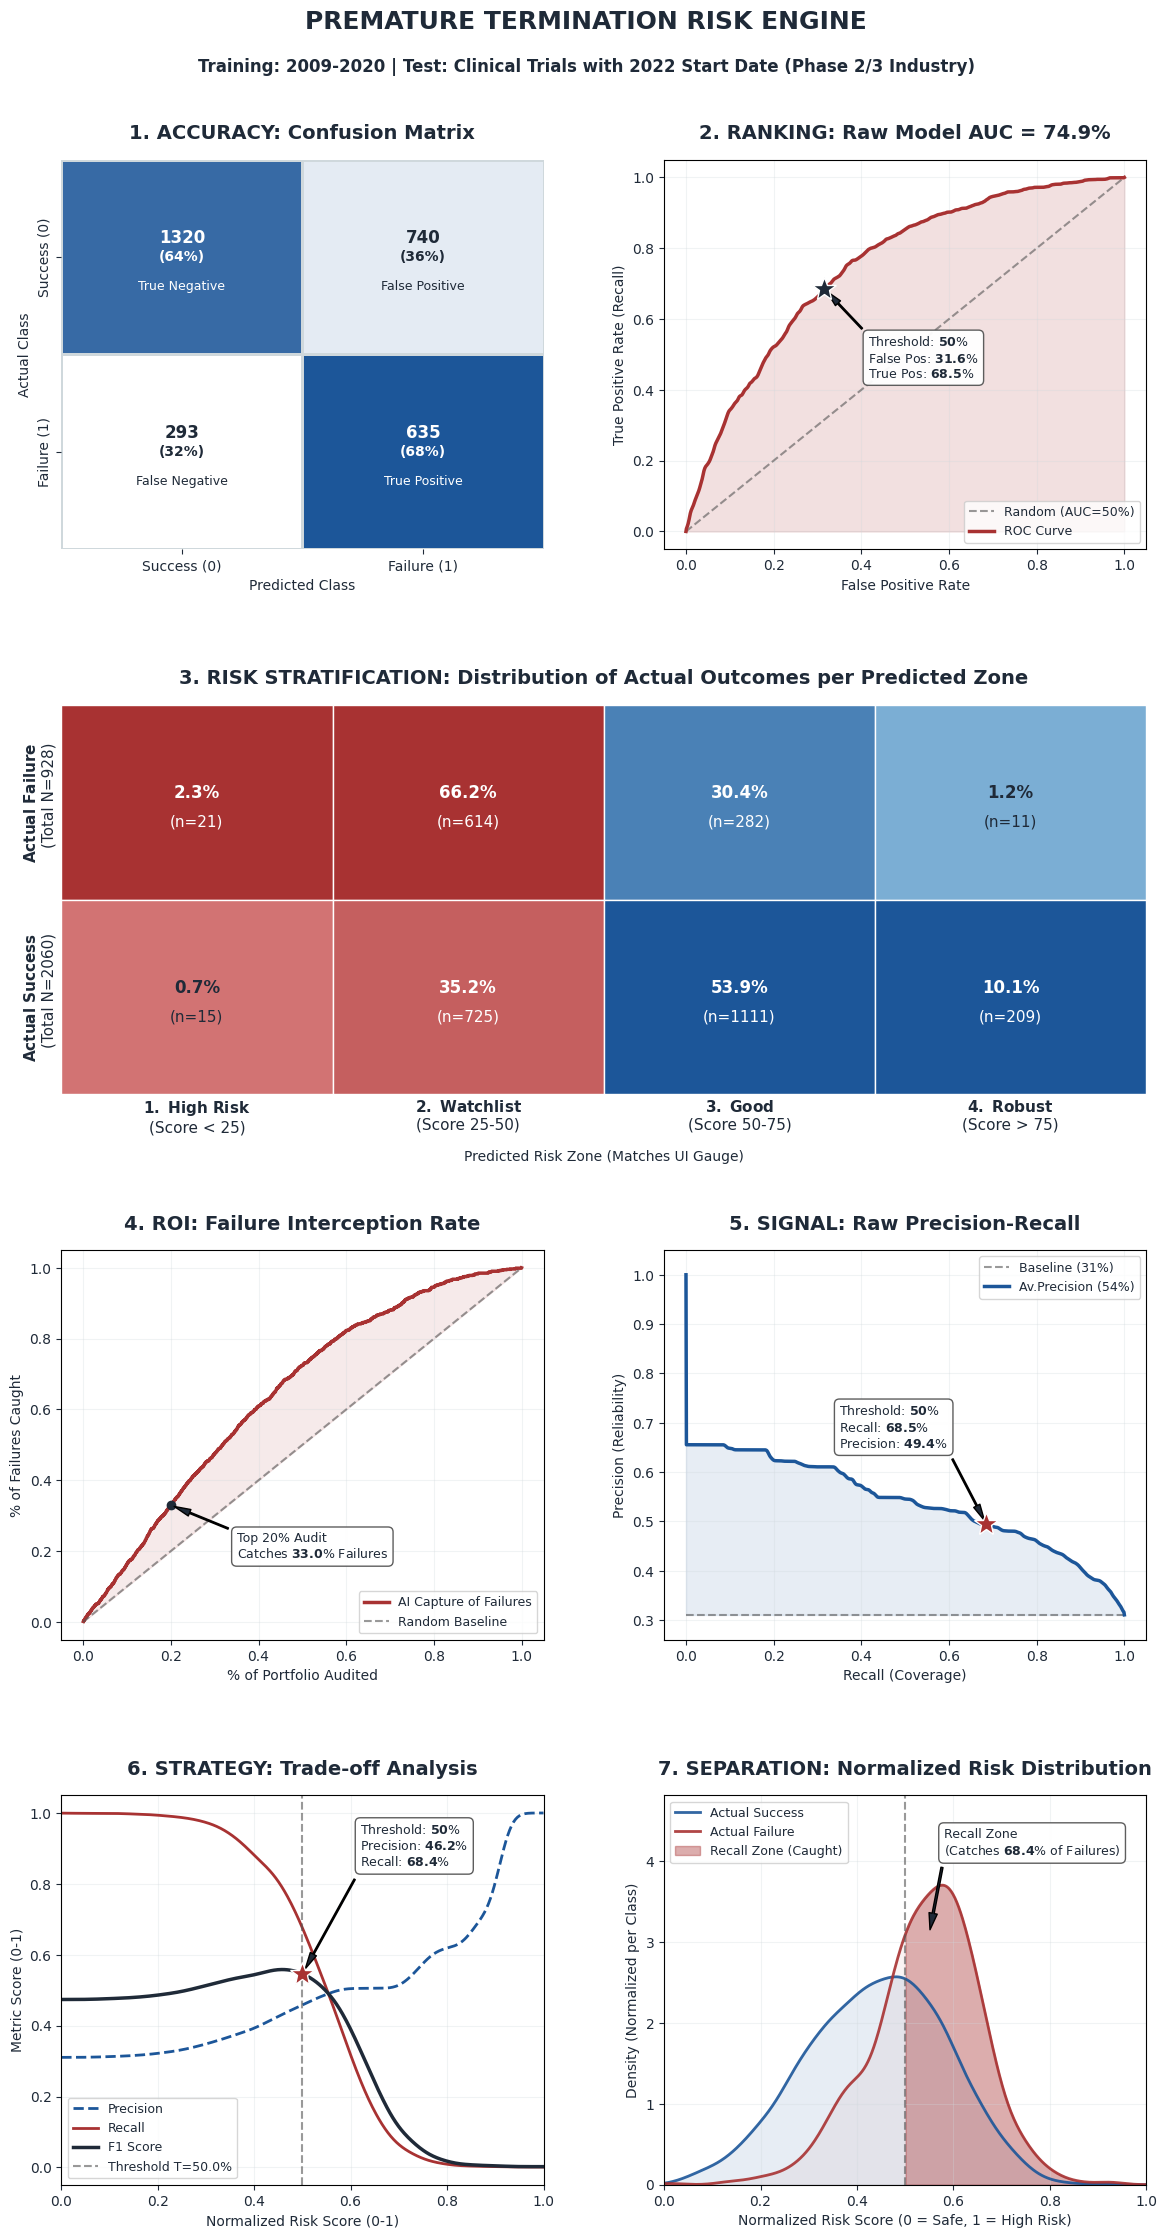

In [17]:
# <REF:PERF_VIS_CODE>
def plot_universal_professional_dashboard(y_true, y_scores_norm, y_scores_raw=None, threshold=0.5):
    """
    Generates the UI-Matched Data Science Dashboard.
    """
    if y_scores_raw is None:
        y_scores_raw = y_scores_norm

    # --- LAYOUT SETUP ---
    fig = plt.figure(figsize=(14, 25), facecolor='white')

    # Global Title
    fig.suptitle("PREMATURE TERMINATION RISK ENGINE",
                 fontsize=18, fontweight='bold', color=UI_COLORS['text_main'], y=0.98)
    fig.text(0.5, 0.955, "Training: 2009-2020 | Test: Clinical Trials with 2022 Start Date (Phase 2/3 Industry)",
             ha='center', fontsize=12, fontweight='bold', color=UI_COLORS['text_main'])

    # Grid Layout
    gs = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.25, top=0.92)

    ax1 = fig.add_subplot(gs[0, 0]) # Accuracy
    ax2 = fig.add_subplot(gs[0, 1]) # ROC
    ax3 = fig.add_subplot(gs[1, :]) # Matrix (Full Width)
    ax4 = fig.add_subplot(gs[2, 0]) # ROI
    ax5 = fig.add_subplot(gs[2, 1]) # PR Curve
    ax6 = fig.add_subplot(gs[3, 0]) # Strategy
    ax7 = fig.add_subplot(gs[3, 1]) # Separation

    # ==========================================================================
    # METRICS CALCULATION
    # ==========================================================================

    # 1. HYBRID STRATEGY (The actual Decision Policy)
    y_pred_hyb = (y_scores_norm >= threshold).astype(int)
    cm_hyb = confusion_matrix(y_true, y_pred_hyb)
    tn_h, fp_h, fn_h, tp_h = cm_hyb.ravel()

    rec_hyb = tp_h / (tp_h + fn_h) if (tp_h + fn_h) > 0 else 0
    prec_hyb = tp_h / (tp_h + fp_h) if (tp_h + fp_h) > 0 else 0
    fpr_hyb = fp_h / (tn_h + fp_h) if (tn_h + fp_h) > 0 else 0

    # 2. RAW MODEL FRONTIER (The Intelligence Curve)
    fpr_raw_arr, tpr_raw_arr, _ = roc_curve(y_true, y_scores_raw)
    p_raw_arr, r_raw_arr, _ = precision_recall_curve(y_true, y_scores_raw)

    # To place the star ON the line and keep numbers consistent with Panel 1:
    idx_roc = np.argmin(np.abs(tpr_raw_arr - rec_hyb))
    star_fpr = fpr_raw_arr[idx_roc]
    star_rec = tpr_raw_arr[idx_roc]

    idx_pr = np.argmin(np.abs(r_raw_arr - rec_hyb))
    star_prec = p_raw_arr[idx_pr]

    # ==========================================================================
    # PANEL 1: ACCURACY (Confusion Matrix)
    # ==========================================================================
    cm_perc = cm_hyb.astype('float') / cm_hyb.sum(axis=1)[:, np.newaxis]
    names = [['True Negative', 'False Positive'], ['False Negative', 'True Positive']]

    sns.heatmap(cm_perc, fmt="", cmap=cmap_conf, ax=ax1, cbar=False,
                linewidths=1, linecolor=UI_COLORS['grid_grey'])

    for i in range(2):
        for j in range(2):
            text_col = "white" if cm_perc[i, j] > 0.5 else UI_COLORS['text_main']
            ax1.text(j + 0.5, i + 0.4, f"{cm_hyb[i, j]}",
                     ha='center', va='center', color=text_col, fontsize=12, fontweight='bold')
            ax1.text(j + 0.5, i + 0.5, f"({cm_perc[i, j]:.0%})",
                     ha='center', va='center', color=text_col, fontsize=10, fontweight='bold')
            ax1.text(j + 0.5, i + 0.65, f"{names[i][j]}",
                     ha='center', va='center', color=text_col, fontsize=9)

    ax1.set_title(f"1. ACCURACY: Confusion Matrix", pad=15, color=UI_COLORS['text_main'])
    ax1.set_xlabel("Predicted Class")
    ax1.set_ylabel("Actual Class")
    ax1.set_xticklabels(['Success (0)', 'Failure (1)'])
    ax1.set_yticklabels(['Success (0)', 'Failure (1)'])

    # ==========================================================================
    # PANEL 2: RANKING (ROC Curve)
    # ==========================================================================
    roc_auc = auc(fpr_raw_arr, tpr_raw_arr)
    fpr_grid = np.linspace(0, 1, 1000)
    tpr_smooth = gaussian_filter1d(np.interp(fpr_grid, fpr_raw_arr, tpr_raw_arr), sigma=2)
    tpr_smooth[0], tpr_smooth[-1] = 0.0, 1.0

    ax2.plot([0, 1], [0, 1], label='Random (AUC=50%)', **ref_line_style)
    ax2.plot(fpr_grid, tpr_smooth, color=UI_COLORS['fail_deep'], lw=2.5, label=f'ROC Curve')
    ax2.fill_between(fpr_grid, tpr_smooth, alpha=0.15, color=UI_COLORS['fail_deep'])

    # Star on the line matching Strategy Recall
    ax2.plot(star_fpr, star_rec, marker='*', ms=18, color=UI_COLORS['text_main'],
             zorder=10, markeredgecolor='white')

    # FIXED: Explicit \n inside the f-string for visual line breaks
    note = (fr"Threshold: $\mathbf{{{threshold*100:.0f}}}$%" + "\n"
            fr"False Pos: $\mathbf{{{star_fpr*100:.1f}}}$%" + "\n"
            fr"True Pos: $\mathbf{{{star_rec*100:.1f}}}$%")
    ax2.annotate(note, xy=(star_fpr, star_rec), xytext=(star_fpr+0.1, star_rec-0.25),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)

    ax2.set_title(f"2. RANKING: Raw Model AUC = {roc_auc:.1%}", pad=15)
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate (Recall)")
    ax2.legend(loc="lower right", frameon=True, fontsize=9)
    ax2.grid(True)

    # ==========================================================================
    # PANEL 3: RISK STRATIFICATION (VIBRANT GRADIENTS)
    # ==========================================================================
    df_matrix = pd.DataFrame({'target': y_true, 'prob': y_scores_norm})

    conditions = [
        (df_matrix['prob'] > 0.75),
        (df_matrix['prob'] > 0.50) & (df_matrix['prob'] <= 0.75),
        (df_matrix['prob'] > 0.25) & (df_matrix['prob'] <= 0.50),
        (df_matrix['prob'] <= 0.25)
    ]
    choices = ["1. High Risk", "2. Watchlist", "3. Good", "4. Robust"]
    df_matrix['Zone'] = np.select(conditions, choices, default="4. Robust")

    total_failures = df_matrix[df_matrix['target'] == 1].shape[0]
    total_successes = df_matrix[df_matrix['target'] == 0].shape[0]

    # FIXED: \n for proper headers
    row_labels_map = {
        0: fr"$\mathbf{{Actual\ Success}}$" + f"\n(Total N={total_successes})",
        1: fr"$\mathbf{{Actual\ Failure}}$" + f"\n(Total N={total_failures})"
    }
    df_matrix['target_label'] = df_matrix['target'].map(row_labels_map)

    col_order = choices
    row_order = [
        fr"$\mathbf{{Actual\ Failure}}$" + f"\n(Total N={total_failures})",
        fr"$\mathbf{{Actual\ Success}}$" + f"\n(Total N={total_successes})"
    ]

    matrix_pct = pd.crosstab(index=df_matrix['target_label'], columns=df_matrix['Zone'], normalize='index')[col_order] * 100
    matrix_counts = pd.crosstab(index=df_matrix['target_label'], columns=df_matrix['Zone'])[col_order]

    matrix_pct = matrix_pct.reindex(row_order).fillna(0)
    matrix_counts = matrix_counts.reindex(row_order).fillna(0)

    # FIXED: \n for zone descriptions
    detailed_labels = [
        fr"$\mathbf{{1.\ High\ Risk}}$" + "\n(Score < 25)",
        fr"$\mathbf{{2.\ Watchlist}}$" + "\n(Score 25-50)",
        fr"$\mathbf{{3.\ Good}}$" + "\n(Score 50-75)",
        fr"$\mathbf{{4.\ Robust}}$" + "\n(Score > 75)"
    ]

    rows = matrix_pct.index
    cols = matrix_pct.columns
    n_rows = len(rows)
    n_cols = len(cols)

    ax3.set_xlim(0, n_cols)
    ax3.set_ylim(0, n_rows)

    for j, col_label in enumerate(cols):
        if "High Risk" in col_label or "Watchlist" in col_label:
            current_cmap = cmap_fail
        else:
            current_cmap = cmap_succ

        val_fail = matrix_pct.loc[row_order[0], col_label]
        val_succ = matrix_pct.loc[row_order[1], col_label]
        max_val = max(val_fail, val_succ)
        if max_val == 0: max_val = 1.0

        for i, row_label in enumerate(rows):
            count = int(matrix_counts.loc[row_label, col_label])
            pct_display = matrix_pct.loc[row_label, col_label]

            intensity = pct_display / max_val
            # Start from 0.15 to keep light colors visible but clear
            rect_color = current_cmap(0.15 + (0.85 * intensity))

            rect = patches.Rectangle((j, n_rows - 1 - i), 1, 1, linewidth=1,
                                     edgecolor='white', facecolor=rect_color)
            ax3.add_patch(rect)

            text_color = 'white' if intensity > 0.5 else UI_COLORS['text_main']

            ax3.text(j + 0.5, n_rows - 1 - i + 0.55, f"{pct_display:.1f}%",
                     ha='center', va='center', fontsize=12, fontweight='bold', color=text_color)
            ax3.text(j + 0.5, n_rows - 1 - i + 0.40, f"(n={count})",
                     ha='center', va='center', fontsize=11, fontweight='normal', color=text_color)

    ax3.set_xticks(np.arange(n_cols) + 0.5)
    ax3.set_xticklabels(detailed_labels, fontsize=11)
    ax3.set_yticks(np.arange(n_rows) + 0.5)
    ax3.set_yticklabels(rows[::-1], fontsize=11, rotation=90, va='center')
    ax3.set_title("3. RISK STRATIFICATION: Distribution of Actual Outcomes per Predicted Zone", pad=15)
    ax3.set_xlabel("Predicted Risk Zone (Matches UI Gauge)", labelpad=10)
    for spine in ax3.spines.values():
        spine.set_visible(False)
    ax3.tick_params(length=0)

    # ==========================================================================
    # PANEL 4: ROI
    # ==========================================================================
    data = pd.DataFrame({'target': y_true, 'prob': y_scores_norm}).sort_values('prob', ascending=False)
    data['cum_pop'] = np.arange(1, len(data) + 1) / len(data)
    data['cum_gain'] = data['target'].cumsum() / data['target'].sum()

    ax4.plot(data['cum_pop'], data['cum_gain'], color=UI_COLORS['fail_deep'], lw=2.5, label='AI Capture of Failures')
    ax4.plot([0, 1], [0, 1], label='Random Baseline', **ref_line_style)
    ax4.fill_between(data['cum_pop'], data['cum_pop'], data['cum_gain'], color=UI_COLORS['fail_deep'], alpha=0.1)

    idx_20 = (data['cum_pop'] - 0.20).abs().idxmin()
    gain_20 = data.loc[idx_20, 'cum_gain']
    ax4.plot(0.20, gain_20, 'o', color=UI_COLORS['text_main'], ms=6)

    # FIXED: \n for ROI note
    ax4.annotate(fr"Top 20% Audit" + "\n" + fr"Catches $\mathbf{{{gain_20*100:.1f}}}$% Failures",
                 xy=(0.20, gain_20), xytext=(0.35, gain_20 - 0.15),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)
    ax4.set_title("4. ROI: Failure Interception Rate", pad=15)
    ax4.set_xlabel("% of Portfolio Audited")
    ax4.set_ylabel("% of Failures Caught")
    ax4.legend(loc="lower right", frameon=True, fontsize=9)
    ax4.grid(True)

    # ==========================================================================
    # PANEL 5: SIGNAL
    # ==========================================================================
    ap = average_precision_score(y_true, y_scores_raw)
    base = y_true.mean()
    r_sort = np.argsort(r_raw_arr)
    p_mono = IsotonicRegression(increasing=False).fit_transform(r_raw_arr[r_sort], p_raw_arr[r_sort])
    r_dense = np.linspace(0, 1, 1000)
    p_smooth = gaussian_filter1d(np.interp(r_dense, r_raw_arr[r_sort], p_mono), sigma=3)
    p_smooth[0], p_smooth[-1] = 1.0, base

    ax5.plot([0, 1], [base, base], label=f'Baseline ({base:.0%})', **ref_line_style)
    ax5.plot(r_dense, p_smooth, color=UI_COLORS['succ_deep'], lw=2.5, label=f'Av.Precision ({ap:.0%})')
    ax5.fill_between(r_dense, p_smooth, base, color=UI_COLORS['succ_deep'], alpha=0.1)

    # Star on the line matching Strategy Recall
    ax5.plot(star_rec, star_prec, marker='*', ms=18, color=UI_COLORS['fail_deep'],
             zorder=10, markeredgecolor='white')

    # FIXED: Explicit \n for PR note
    note_pr = (fr"Threshold: $\mathbf{{{threshold*100:.0f}}}$%" + "\n"
               fr"Recall: $\mathbf{{{star_rec*100:.1f}}}$%" + "\n"
               fr"Precision: $\mathbf{{{star_prec*100:.1f}}}$%")
    ax5.annotate(note_pr, xy=(star_rec, star_prec), xytext=(0.35, 0.65),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)
    ax5.set_title("5. SIGNAL: Raw Precision-Recall", pad=15)
    ax5.set_xlabel("Recall (Coverage)")
    ax5.set_ylabel("Precision (Reliability)")
    ax5.set_ylim(base-0.05, 1.05)
    ax5.legend(loc="upper right", frameon=True, fontsize=9)
    ax5.grid(True)

    # ==========================================================================
    # PANEL 6: STRATEGY
    # ==========================================================================
    p_trade, r_trade, t_trade = precision_recall_curve(y_true, y_scores_norm)
    p_trade, r_trade = p_trade[:-1], r_trade[:-1]
    t_grid = np.linspace(0, 1, 500)
    p_smooth_line = gaussian_filter1d(np.interp(t_grid, t_trade, IsotonicRegression(increasing=True).fit_transform(t_trade, p_trade)), sigma=10)
    r_smooth_line = gaussian_filter1d(np.interp(t_grid, t_trade, IsotonicRegression(increasing=False).fit_transform(t_trade, r_trade)), sigma=10)
    f1_smooth_line = 2*(p_smooth_line*r_smooth_line)/(p_smooth_line+r_smooth_line+1e-8)

    ax6.plot(t_grid, p_smooth_line, color=UI_COLORS['succ_deep'], linestyle='--', lw=2, label="Precision")
    ax6.plot(t_grid, r_smooth_line, color=UI_COLORS['fail_deep'], linestyle='-', lw=2, label="Recall")
    ax6.plot(t_grid, f1_smooth_line, color=UI_COLORS['text_main'], linestyle='-', lw=2.5, label="F1 Score")
    ax6.axvline(threshold, label=f'Threshold T={threshold:.1%}', **ref_line_style)

    idx_thresh = np.argmin(np.abs(t_grid - threshold))
    f1_at_thresh = f1_smooth_line[idx_thresh]
    ax6.plot(threshold, f1_at_thresh, marker='*', ms=18, color=UI_COLORS['fail_deep'],
             zorder=10, markeredgecolor='white')

    # FIXED: Explicit \n for Strategy note
    strat_text = (fr"Threshold: $\mathbf{{{threshold*100:.0f}}}$%" + "\n"
                  fr"Precision: $\mathbf{{{prec_hyb*100:.1f}}}$%" + "\n"
                  fr"Recall: $\mathbf{{{rec_hyb*100:.1f}}}$%")
    ax6.annotate(strat_text, xy=(threshold, f1_at_thresh), xytext=(0.62, 0.85),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)
    ax6.set_title("6. STRATEGY: Trade-off Analysis", pad=15)
    ax6.set_xlabel("Normalized Risk Score (0-1)")
    ax6.set_ylabel("Metric Score (0-1)")
    ax6.legend(loc="lower left", frameon=True, fontsize=9)
    ax6.grid(True)
    ax6.set_xlim(0, 1.0)

    # ==========================================================================
    # PANEL 7: SEPARATION
    # ==========================================================================
    x_grid = np.linspace(0, 1, 500)
    kde_succ = gaussian_kde(y_scores_norm[y_true == 0])
    kde_fail = gaussian_kde(y_scores_norm[y_true == 1])
    y_succ_balanced = kde_succ(x_grid)
    y_fail_balanced = kde_fail(x_grid)

    ax7.plot(x_grid, y_succ_balanced, color=UI_COLORS['succ_deep'], alpha=0.9, lw=2, label='Actual Success')
    ax7.fill_between(x_grid, 0, y_succ_balanced, color=UI_COLORS['succ_deep'], alpha=0.1)
    ax7.plot(x_grid, y_fail_balanced, color=UI_COLORS['fail_deep'], alpha=0.9, lw=2, label='Actual Failure')
    ax7.fill_between(x_grid, 0, y_fail_balanced, where=(x_grid >= threshold),
                     color=UI_COLORS['fail_deep'], alpha=0.4, label='Recall Zone (Caught)')
    ax7.fill_between(x_grid, 0, y_fail_balanced, where=(x_grid < threshold),
                     color=UI_COLORS['fail_deep'], alpha=0.05)
    ax7.axvline(threshold, **ref_line_style)

    max_density = max(y_succ_balanced.max(), y_fail_balanced.max())
    ax7.set_ylim(0, max_density * 1.3)

    # FIXED: \n for Separation note
    ax7.annotate(fr"Recall Zone" + "\n" + fr"(Catches $\mathbf{{{rec_hyb*100:.1f}}}$% of Failures)",
                        xy=(threshold + 0.05, y_fail_balanced[np.argmin(np.abs(x_grid - threshold))]),
                        xytext=(0.58, max_density * 1.1),
                        arrowprops=dict(facecolor=UI_COLORS['text_main'], shrink=0.05, width=1.5, headwidth=6),
                        bbox=box_style, fontsize=9)
    ax7.set_title("7. SEPARATION: Normalized Risk Distribution", pad=15)
    ax7.set_xlabel("Normalized Risk Score (0 = Safe, 1 = High Risk)")
    ax7.set_ylabel("Density (Normalized per Class)")
    ax7.legend(loc="upper left", frameon=True, fontsize=9)
    ax7.grid(True)
    ax7.set_xlim(0, 1.0)

    plt.show()

# --- EXECUTE ---
print(">>> Rendering Final UI-Matched Dashboard...")
# --- SYNC LOGIC: Forced Data Refresh ---
# We re-patch test_results here to ensure strategy changes flow into the plots.
test_results = X_test.copy()
test_results['target'] = y_test
test_results['proba_1'] = y_prob
test_results['risk_score_norm'] = 1.0 - (df_scores['Clinical_Score'] / 100.0)

plot_universal_professional_dashboard(
    y_true=test_results['target'],
    y_scores_norm=test_results['risk_score_norm'],
    y_scores_raw=test_results['proba_1'],
    threshold=0.5
)
# <REF:/PERF_VIS_CODE>


#### <REF:UI_VIS>
> #### **14. Individual Trial Profiler: Production APP UI Snapshot**

This module demonstrates the individual-level output used in the production application. The **Clinical Success Score** is presented via a vibrant gauge, providing instant visual context—from 'High Risk' (Red) to 'Robust' (Gold)—to support rapid, high-confidence decision-making.

In [18]:
# <REF:UI_VIS_CODE>
Trial_Example = 40

print(f"\n>>> FINAL STEP: UI VISUALIZATION SNAPSHOT FOR TRIAL ID {Trial_Example}...")


import plotly.graph_objects as go
import pandas as pd
import numpy as np
import re
import textwrap

# ==============================================================================
# 0. UNIFIED STYLE CONFIGURATION (UPDATED TO VIBRANT PALETTE)
# ==============================================================================
STYLE_CONFIG = {
    # FONTS
    "font_family": "Arial",
    "font_size_header": 16,
    "font_size_body": 14,
    "font_color": "#1f2a38", # Dark Navy/Black

    # COLOR PALETTE (Vibrant Professional - Matches Data Science Graph)
    # We converted the HEX codes from the previous step into RGB tuples here.
    "colors": {
        # High Risk (Fail Deep): #A83232
        "red_deep":   (168, 50, 50),

        # Watchlist (Fail Soft): #F0A3A3
        "red_soft":   (240, 163, 163),

        # Center Neutral
        "grey_warm":  (242, 244, 248),

        # Good (Succ Soft): #9ACBE8
        "blue_soft":  (154, 203, 232),

        # Robust (Succ Deep): #1C5699
        "blue_deep":  (28, 86, 153),

        # Static Colors
        "therapeutic_grey": "#CFD8DC",
        "separator_white": "white"
    }
}

def get_rgb_str(rgb_tuple):
    """Converts (r,g,b) tuple to 'rgb(r,g,b)' string."""
    return f"rgb({rgb_tuple[0]},{rgb_tuple[1]},{rgb_tuple[2]})"

def interpolate_color(c1, c2, ratio):
    """Linearly interpolates between two RGB tuples."""
    r = int(c1[0] + (c2[0] - c1[0]) * ratio)
    g = int(c1[1] + (c2[1] - c1[1]) * ratio)
    b = int(c1[2] + (c2[2] - c1[2]) * ratio)
    return (r, g, b)

def get_contrast_color(r, g, b):
    """Utility for contrast text (White vs Black)."""
    rs, gs, bs = r / 255.0, g / 255.0, b / 255.0
    L = 0.2126 * rs + 0.7152 * gs + 0.0722 * bs
    return "#000000" if L > 0.6 else "#FFFFFF"

def mix_white(rgb, factor=0.7):
    """Mixes a color with white to create a lighter 'pastel' version."""
    r, g, b = rgb
    new_r = int(r + (255 - r) * factor)
    new_g = int(g + (255 - g) * factor)
    new_b = int(b + (255 - b) * factor)
    return (new_r, new_g, new_b)

def fmt_header(text, value, txt_color="black", split=False):
    """Standardized Header Format."""
    if split:
        label = f"{text}<br>({value:+.1f}%)"
    else:
        label = f"{text} ({value:+.1f}%)"
    return (
        f"<span style='font-size:14px; font-weight:bold; color:{txt_color}'>"
        f"{label}"
        f"</span>"
    )

# ==============================================================================
# 1. GAUGE CHART
# ==============================================================================
print("\n=== STEP 14: CLINICAL SCORE GAUGE (VIBRANT) ===")

def plot_risk_gauge(score_val):
    steps = []
    n_slices = 100
    c = STYLE_CONFIG["colors"]

    for i in range(n_slices):
        v_start, v_end = i, i + 1
        if i < 25:
            color = interpolate_color(c["red_deep"], c["red_soft"], i / 25.0)
        elif i < 50:
            color = interpolate_color(c["red_soft"], c["grey_warm"], (i - 25) / 25.0)
        elif i < 75:
            color = interpolate_color(c["grey_warm"], c["blue_soft"], (i - 50) / 25.0)
        else:
            color = interpolate_color(c["blue_soft"], c["blue_deep"], (i - 75) / 25.0)
        steps.append({'range': [v_start, v_end], 'color': get_rgb_str(color)})

    for sep in [25, 50, 75]:
        steps.append({'range': [sep - 0.5, sep + 0.5], 'color': 'white'})

    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=score_val,
        number={
            "suffix": "",
            "valueformat": ".1f",
            "font": {"size": 52, "color": STYLE_CONFIG["font_color"],
                     "family": STYLE_CONFIG["font_family"], "weight": "bold"}
        },
        domain={"x": [0, 1], "y": [0, 1]},
        gauge={
            "axis": {
                "range": [0, 100],
                "tickmode": "array",
                "tickvals": [0, 25, 50, 75, 100],
                "ticktext": ["0", "25", "50", "75", "100"],
                "ticklen": 0, "tickwidth": 0, "tickcolor": "white",
                "tickfont": {"size": STYLE_CONFIG["font_size_body"],
                             "color": "#555555",
                             "family": STYLE_CONFIG["font_family"], "weight": "bold"},
            },
            "bar": {"color": "rgba(0,0,0,0)"},
            "bgcolor": "white",
            "borderwidth": 0,
            "steps": steps,
            "threshold": {
                "line": {"color": STYLE_CONFIG["font_color"], "width": 5},
                "thickness": 0.75,
                "value": score_val
            },
        },
    ))
    fig.update_layout(
        margin=dict(l=35, r=35, t=40, b=10),
        paper_bgcolor="white",
        font={"family": STYLE_CONFIG["font_family"], "color": "#333333"},
        height=220,
        hovermode=False
    )
    fig.update_traces(gauge_bar_thickness=0.75)
    return fig

# ==============================================================================
# 2. IMPACT BAR CHART (VIBRANT EDGES + UNIFORM GRADIENT)
# ==============================================================================
print("\n=== STEP 14: INDIVIDUAL TRIAL PROFILER (VIBRANT EDGES) ===")

def get_pillar_impacts(df_scores, trial_index):
    # Standard data extraction
    meta_cols = ['Clinical_Score', 'Therapeutic_Area', 'Phase', 'Internal_Score_Raw', 'Zone', 'CALIBRATION_OFFSET']
    pillar_cols = [c for c in df_scores.columns if c not in meta_cols]
    row = df_scores.loc[trial_index, pillar_cols].copy()

    # Redundant sync removed (already handled in scorecard generation)

    df_impact = pd.DataFrame({'Pillar': row.index, 'Impact': row.values})
    df_impact['Pillar_Clean'] = df_impact['Pillar'].apply(lambda x: re.sub(r'^\\d+\\.\\s*', '', x))
    df_impact['Label'] = df_impact['Impact'].apply(lambda x: f"{x:+.1f}%")

    # Sort by impact for the plot
    df_impact = df_impact.sort_values(by='Impact', ascending=True)
    return df_impact

def plot_impact_bar(df_impact, trial_id, score):
    max_val = df_impact['Impact'].abs().max()
    limit = max_val * 1.35

    # --- CONFIGURATION ---
    SLICE_STEP = 0.08      # Fixed width slices for uniform look
    BAR_WIDTH = 0.75       # Bar Thickness

    # TUNING KNOB 1: SATURATION POINT
    # Lower = Reaches "Deep" color faster (Darker Edges)
    # 4.0 means any bar > 4% will have a fully dark tip.
    GLOBAL_MAX_SCALE = 4.0

    # Colors
    c = STYLE_CONFIG["colors"]
    center_grey = c["grey_warm"]

    # Helper
    def hex_to_rgb(hex_str):
        hex_str = hex_str.lstrip('#')
        return tuple(int(hex_str[i:i+2], 16) for i in (0, 2, 4))

    fig = go.Figure()

    # Calculate how many steps we need
    total_steps = int(np.ceil(max_val / SLICE_STEP))

    for i in range(total_steps):
        current_abs_pos = i * SLICE_STEP

        slice_widths = []
        slice_colors = []
        slice_texts = []

        for idx, val in enumerate(df_impact['Impact']):
            abs_val = abs(val)
            pillar_name = df_impact['Pillar'].iloc[idx]

            # 1. Calculate Width
            if current_abs_pos >= abs_val:
                w = 0
                is_tip = False
            elif current_abs_pos + SLICE_STEP > abs_val:
                w = abs_val - current_abs_pos
                is_tip = True
            else:
                w = SLICE_STEP
                is_tip = False

            if val < 0: w = -w
            slice_widths.append(w)

            # 2. Label
            if is_tip:
                slice_texts.append(df_impact['Label'].iloc[idx])
            else:
                slice_texts.append(None)

            # 3. Calculate Color
            color_pos = current_abs_pos + (abs(w) / 2)

            # Special Case: Therapeutic Area
            if "Therapeutic" in pillar_name:
                hex_val = STYLE_CONFIG["colors"]["therapeutic_grey"]
                rgb = hex_to_rgb(hex_val)
                slice_colors.append(f"rgb({rgb[0]},{rgb[1]},{rgb[2]})")
                continue

            # --- INTENSITY LOGIC ---
            ratio = min(color_pos / GLOBAL_MAX_SCALE, 1.0)

            # TUNING KNOB 2: ACCELERATION
            # 0.5 makes the color ramp up stronger in the middle
            ratio = ratio ** 0.5

            if val >= 0:
                # POSITIVE
                if ratio < 0.5:
                    local_ratio = ratio * 2
                    final_rgb = interpolate_color(center_grey, c["blue_soft"], local_ratio)
                else:
                    local_ratio = (ratio - 0.5) * 2
                    final_rgb = interpolate_color(c["blue_soft"], c["blue_deep"], local_ratio)
            else:
                # NEGATIVE
                if ratio < 0.5:
                    local_ratio = ratio * 2
                    final_rgb = interpolate_color(center_grey, c["red_soft"], local_ratio)
                else:
                    local_ratio = (ratio - 0.5) * 2
                    final_rgb = interpolate_color(c["red_soft"], c["red_deep"], local_ratio)

            slice_colors.append(f"rgb({final_rgb[0]},{final_rgb[1]},{final_rgb[2]})")

        # Add Trace
        fig.add_trace(go.Bar(
            y=df_impact['Pillar_Clean'],
            x=slice_widths,
            orientation='h',
            width=BAR_WIDTH,
            marker=dict(
                color=slice_colors,
                line=dict(width=0)
            ),
            text=slice_texts,
            textposition='outside',
            textfont=dict(size=STYLE_CONFIG["font_size_body"], color="black", family=STYLE_CONFIG["font_family"]),
            hoverinfo='skip',
            showlegend=False
        ))

    # Vertical Line at 0
    fig.add_vline(x=0, line_width=1, line_color="#333333")

    fig.update_layout(
        barmode='relative',
        xaxis=dict(showticklabels=False, showgrid=False, zeroline=False, range=[-limit, limit]),
        yaxis=dict(showticklabels=True, tickfont=dict(size=STYLE_CONFIG["font_size_body"], color="black", family=STYLE_CONFIG["font_family"]), automargin=True),
        margin=dict(l=10, r=10, t=50, b=10),
        plot_bgcolor="white", paper_bgcolor="white", height=300, showlegend=False
    )
    return fig
# ==============================================================================
# 3. TREEMAP
# ==============================================================================
print("\n=== STEP 14: VISUALIZATION (VIBRANT TREEMAP) ===")

def plot_smart_treemap(shap_values, feature_names, trial_index, taxonomy, gain_factor, df_scores):
    try:
        pos_idx = df_scores.index.get_loc(trial_index)
        row_shap = shap_values[pos_idx]
        calib_credit = df_scores.loc[trial_index, 'CALIBRATION_OFFSET']
    except: return go.Figure()

    nodes = {}
    node_sums = {"ALL_DRIVERS": 0.0, "OPERATIONAL_DRIVERS": 0.0, "THERAPEUTIC_CONTEXT": 0.0}
    c = STYLE_CONFIG["colors"]
    leaf_data = []

    for pillar_raw, topics in taxonomy.items():
        pillar_clean = pillar_raw.split(". ")[1]
        is_therapeutic = "Therapeutic" in pillar_raw
        parent_id = "THERAPEUTIC_CONTEXT" if is_therapeutic else f"PILLAR_{pillar_clean}"
        if parent_id not in node_sums: node_sums[parent_id] = 0.0

        for subtopic, details in topics.items():
            prefixes = details['features']
            impact = 0.0
            shap_prefixes = [p for p in prefixes if p != "CALIBRATION_OFFSET"]
            if shap_prefixes:
                total_shap = sum(row_shap[i] for i, f in enumerate(feature_names) if any(f.startswith(p) for p in shap_prefixes))
                impact += (total_shap * gain_factor * -1)
            if "CALIBRATION_OFFSET" in prefixes:
                impact += calib_credit

            narrative = details['pos_impact'] if impact >= 0 else details['neg_impact']
            ratio = min(abs(impact) / 8.0, 1.0)
            ratio = max(0.2, ratio)

            if is_therapeutic:
                r, g, b = (207, 216, 220)
                txt_color = "black"
            elif impact >= 0:
                r, g, b = interpolate_color(c["blue_soft"], c["blue_deep"], ratio)
                txt_color = "white"
            else:
                r, g, b = interpolate_color(c["red_soft"], c["red_deep"], ratio)
                txt_color = "white"

            bg_hex = get_rgb_str((r,g,b))
            wrapped_narrative = '<br>'.join(textwrap.wrap(narrative, width=30))
            label_html = (
                f"<span style='font-size:15px; font-weight:bold; color:{txt_color}'>{subtopic}</span>"
                f"<br><span style='font-size:14px; color:{txt_color}'>{impact:+.1f}%</span>"
                f"<br><br><span style='font-size:13px; font-style:normal; color:{txt_color}'>{wrapped_narrative}</span>"
            )

            leaf_id = f"{parent_id}_{subtopic}"
            node_sums[leaf_id] = impact
            node_sums[parent_id] += impact
            node_sums["ALL_DRIVERS"] += impact
            if not is_therapeutic: node_sums["OPERATIONAL_DRIVERS"] += impact

            leaf_data.append({"id": leaf_id, "parent": parent_id, "label": label_html, "color": bg_hex, "value": abs(impact)})

    def get_header_color(val, is_grey=False):
        if is_grey: return "#ECEFF1"
        ratio = min(abs(val) / 8.0, 1.0)
        if val >= 0:
            base_rgb = interpolate_color(c["blue_soft"], c["blue_deep"], ratio)
        else:
            base_rgb = interpolate_color(c["red_soft"], c["red_deep"], ratio)
        pastel_rgb = mix_white(base_rgb, factor=0.7)
        return get_rgb_str(pastel_rgb)

    for pillar_raw in taxonomy.keys():
        if "Therapeutic" not in pillar_raw:
            p_clean = pillar_raw.split(". ")[1]
            p_id = f"PILLAR_{p_clean}"
            if p_id in node_sums:
                val = node_sums[p_id]
                nodes[p_id] = {"parent": "OPERATIONAL_DRIVERS", "label": fmt_header(p_clean.upper(), val, txt_color="black"), "color": get_header_color(val), "value": 0}

    ther_val = node_sums["THERAPEUTIC_CONTEXT"]
    nodes["THERAPEUTIC_CONTEXT"] = {"parent": "ALL_DRIVERS", "label": fmt_header("THERAPEUTIC CONTEXT", ther_val, txt_color="black"), "color": "#ECEFF1", "value": 0}

    ops_val = node_sums["OPERATIONAL_DRIVERS"]
    nodes["OPERATIONAL_DRIVERS"] = {"parent": "ALL_DRIVERS", "label": fmt_header("OPERATIONAL DRIVERS", ops_val, txt_color="black"), "color": get_header_color(ops_val), "value": 0}

    root_val = node_sums["ALL_DRIVERS"]
    nodes["ALL_DRIVERS"] = {"parent": "", "label": fmt_header("ALL DRIVERS", root_val, txt_color="black"), "color": "#FFFFFF", "value": 0}

    for item in leaf_data:
        nodes[item['id']] = {"parent": item['parent'], "label": item['label'], "color": item['color'], "value": item['value']}

    ids = list(nodes.keys())
    fig = go.Figure(go.Treemap(
        ids=ids,
        labels=[nodes[k]['label'] for k in ids],
        parents=[nodes[k]['parent'] for k in ids],
        values=[nodes[k]['value'] for k in ids],
        marker=dict(colors=[nodes[k]['color'] for k in ids], line=dict(width=1, color='white')),
        textinfo="label", textposition="top left", tiling=dict(packing="squarify"), hoverinfo="skip",
        pathbar=dict(visible=True, thickness=30, textfont=dict(family="Arial", size=11))
    ))
    fig.update_layout(margin=dict(t=34, l=15, r=15, b=15), height=600, font=dict(family="Arial"), paper_bgcolor='white', hovermode=False)
    return fig

# ==============================================================================
# 4. EXECUTION
# ==============================================================================
target_idx = df_scores.index[Trial_Example]
score_val = df_scores.loc[target_idx, 'Clinical_Score']

# 1. Gauge
fig_gauge = plot_risk_gauge(score_val)
fig_gauge.show()

# 2. Bar Chart
df_impact_test = get_pillar_impacts(df_scores, target_idx)
fig_bar = plot_impact_bar(df_impact_test, target_idx, score_val)
fig_bar.show()

# 3. Treemap
fig_tree = plot_smart_treemap(shap_values, feature_names, target_idx, RISK_TAXONOMY, GAIN_FACTOR, df_scores)
fig_tree.show()

# <REF:/UI_VIS_CODE>


>>> FINAL STEP: UI VISUALIZATION SNAPSHOT FOR TRIAL ID 40...

=== STEP 14: CLINICAL SCORE GAUGE (VIBRANT) ===

=== STEP 14: INDIVIDUAL TRIAL PROFILER (VIBRANT EDGES) ===

=== STEP 14: VISUALIZATION (VIBRANT TREEMAP) ===


#### <REF:ROLLING_VALID>
> #### **15. Rolling Validation: Overall Model Robustness Check**

**Objective**
This module executes a rigorous **Time-Series Cross-Validation** to assess the model's temporal stability and generalization capabilities across the full 2009–2022 timeline.

**Rationale**
Standard randomized Cross-Validation (K-Fold) is invalid for time-dependent data as it introduces "Look-Ahead Bias" (training on future data to predict the past). To accurately simulate real-world deployment, this module utilizes a **Rolling Origin** approach. This ensures the model is evaluated on its ability to adapt to evolving clinical standards, changing regulatory environments, and shifting baseline failure rates.

**Methodology (Step-by-Step)**

1.  **Data Unification & Sorting**
    *   **Code Reference:** `pd.concat`, `sort_values(by=['start_date'])`
    *   **Logic:** The Training and Test sets are merged and strictly ordered by `start_date`. This reconstructs the complete historical timeline of clinical trials.

2.  **Rolling Origin Splitting**
    *   **Code Reference:** `TimeSeriesSplit(n_splits=6)`
    *   **Logic:** The timeline is divided into expanding windows.
        *   *Fold 1:* Train on [2009–2011], Predict [2012].
        *   *Fold 2:* Train on [2009–2013], Predict [2014].
        *   *Result:* This simulates the model's performance as if it were retrained annually with new data.

3.  **Leakage Prevention**
    *   **Code Reference:** `cols_to_exclude`, `drop(columns=drop_cols)`
    *   **Logic:** Metadata columns required for sorting (e.g., `start_date`, `nct_id`) are explicitly removed *immediately* before the training step. This ensures the model learns solely from the blinded protocol features.

4.  **Stability Analysis (Dual-Axis Plot)**
    *   **Code Reference:** `plot_unified_stability`
    *   **Logic:** Two metrics are visualized simultaneously to contextualize performance:
        *   **Model Performance (AUC):** The primary line graph tracking predictive power over time.
        *   **Data Difficulty (Failure Rate):** The secondary axis tracking the prevalence of failure in the training set. This helps determine if performance fluctuations are due to model degradation or changes in the underlying market difficulty.

<REF:/ROLLING_VALID>

>>> Merging and Sorting Data for Unified Timeline...
    [Check] Data Sorted from 2009-01-01 to 2022-12-31
    [Check] Total Trials: 24592

>>> Starting Detailed CV (6 folds)...
Fold 1: Train[2009-01-01 -> 2010-10-31] Val[2010-10-31 -> 2012-08-31] AUC: 0.6493
Fold 2: Train[2009-01-01 -> 2012-08-31] Val[2012-08-31 -> 2014-06-30] AUC: 0.6516
Fold 3: Train[2009-01-01 -> 2014-06-30] Val[2014-06-30 -> 2016-05-31] AUC: 0.7146
Fold 4: Train[2009-01-01 -> 2016-05-31] Val[2016-05-31 -> 2018-06-20] AUC: 0.6878
Fold 5: Train[2009-01-01 -> 2018-06-20] Val[2018-06-20 -> 2020-09-24] AUC: 0.7032
Fold 6: Train[2009-01-01 -> 2020-09-24] Val[2020-09-24 -> 2022-12-31] AUC: 0.7398

FINAL TEMPORAL VALIDATION REPORT
 Fold Train_Start  Train_End  Train_Count Train_Fail_Rate  Val_Start    Val_End  Val_Count Val_Fail_Rate ROC_AUC PR_AUC
    1  2009-01-01 2010-10-31         3514           15.3% 2010-10-31 2012-08-31       3513         15.9%  0.6493 0.2346
    2  2009-01-01 2012-08-31         7027           15.6

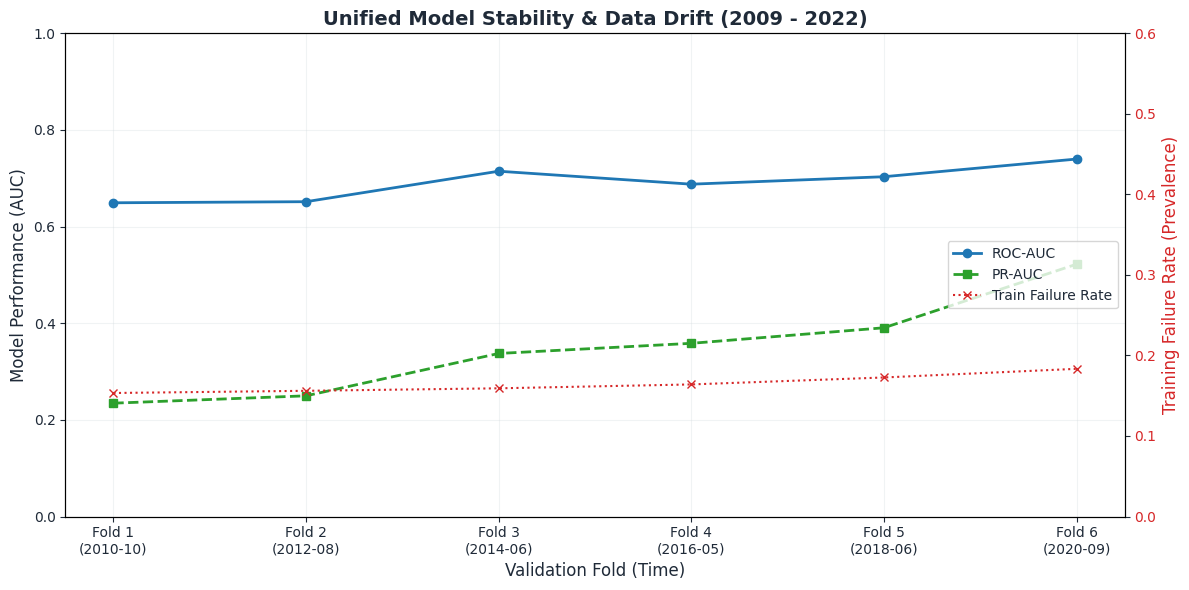

In [19]:
# <REF:ROLLING_VALID_CODE>
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.base import clone

# ==============================================================================
# STEP A: DEFINE THE ROLLING VALIDATION ENGINE
# ==============================================================================
def run_detailed_unified_cv(model_pipeline, X_train, y_train, X_test, y_test, n_splits=6):
    """
    Runs Rolling Origin CV using 'start_date' found directly inside X.
    Automatically drops 'start_date' before training to prevent leakage.
    """

    # --- 1. MERGE & SORT (CRITICAL) ---
    print(f">>> Merging and Sorting Data for Unified Timeline...")
    X_full = pd.concat([X_train, X_test])
    y_full = pd.concat([y_train, y_test])

    # Check if start_date exists
    if 'start_date' not in X_full.columns:
        raise KeyError("Column 'start_date' not found in X. Please ensure it is present.")

    # STRICT SORT: Sort by Date
    # We use the index as a tiebreaker to ensure deterministic sorting
    sort_indices = X_full.sort_values(by=['start_date']).index

    X_full = X_full.loc[sort_indices]
    y_full = y_full.loc[sort_indices]

    print(f"    [Check] Data Sorted from {X_full['start_date'].iloc[0]} to {X_full['start_date'].iloc[-1]}")
    print(f"    [Check] Total Trials: {len(X_full)}")

    # --- 2. INITIALIZE SPLITTER ---
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    # Define columns to exclude from training (Metadata)
    # We remove these JUST before fitting so the model doesn't cheat
    cols_to_exclude = ['start_date', 'nct_id']

    print(f"\n>>> Starting Detailed CV ({n_splits} folds)...")

    # --- 3. EXECUTE LOOP ---
    for fold_idx, (train_ix, val_ix) in enumerate(tscv.split(X_full)):

        # A. Slice Data (Keep Metadata for now)
        X_f_train_raw = X_full.iloc[train_ix]
        X_f_val_raw   = X_full.iloc[val_ix]
        y_f_train     = y_full.iloc[train_ix]
        y_f_val       = y_full.iloc[val_ix]

        # B. Capture Metadata (Using the columns before we drop them)
        meta = {
            'Fold': fold_idx + 1,
            # Train Metadata
            'Train_Start': X_f_train_raw['start_date'].min(),
            'Train_End':   X_f_train_raw['start_date'].max(),
            'Train_Count': len(X_f_train_raw),
            'Train_Fail_Rate': y_f_train.mean(),
            # Val Metadata
            'Val_Start': X_f_val_raw['start_date'].min(),
            'Val_End':   X_f_val_raw['start_date'].max(),
            'Val_Count': len(X_f_val_raw),
            'Val_Fail_Rate': y_f_val.mean()
        }

        # C. DROP METADATA (Prevent Leakage)
        # We drop columns that exist in the dataframe
        drop_cols = [c for c in cols_to_exclude if c in X_f_train_raw.columns]
        X_f_train = X_f_train_raw.drop(columns=drop_cols)
        X_f_val   = X_f_val_raw.drop(columns=drop_cols)

        # D. Train & Predict
        fold_model = clone(model_pipeline)
        fold_model.fit(X_f_train, y_f_train)
        y_pred_prob = fold_model.predict_proba(X_f_val)[:, 1]

        # E. Score
        meta['ROC_AUC'] = roc_auc_score(y_f_val, y_pred_prob)
        meta['PR_AUC']  = average_precision_score(y_f_val, y_pred_prob)

        results.append(meta)

        # F. Console Log
        print(f"Fold {meta['Fold']}: Train[{str(meta['Train_Start'])[:10]} -> {str(meta['Train_End'])[:10]}] "
              f"Val[{str(meta['Val_Start'])[:10]} -> {str(meta['Val_End'])[:10]}] "
              f"AUC: {meta['ROC_AUC']:.4f}")

    return pd.DataFrame(results)

def plot_unified_stability(cv_results):
    """
    Plots Model Performance vs. Training Failure Rate
    """
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- Axis 1: Performance Metrics ---
    ax1.set_xlabel('Validation Fold (Time)', fontsize=12)
    ax1.set_ylabel('Model Performance (AUC)', fontsize=12)

    l1 = ax1.plot(cv_results['Fold'], cv_results['ROC_AUC'], marker='o', color='tab:blue', label='ROC-AUC', linewidth=2)
    l2 = ax1.plot(cv_results['Fold'], cv_results['PR_AUC'], marker='s', color='tab:green', label='PR-AUC', linewidth=2, linestyle='--')

    ax1.set_ylim(0.0, 1.0)
    ax1.grid(True, alpha=0.3)

    # --- Axis 2: Data Context (Failure Rate) ---
    ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
    ax2.set_ylabel('Training Failure Rate (Prevalence)', fontsize=12, color='tab:red')

    l3 = ax2.plot(cv_results['Fold'], cv_results['Train_Fail_Rate'], marker='x', color='tab:red', label='Train Failure Rate', linestyle=':', linewidth=1.5)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.set_ylim(0.0, 0.6)

    # --- Formatting ---
    lns = l1 + l2 + l3
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='center right')

    # X-Axis Labels
    dates = cv_results['Val_Start'].astype(str).str[:7].tolist()
    plt.xticks(cv_results['Fold'], [f"Fold {i}\n({d})" for i, d in zip(cv_results['Fold'], dates)])

    plt.title("Unified Model Stability & Data Drift (2009 - 2022)", fontsize=14)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# STEP B: PREPARE DATA (RESTORE DATES)
# ==============================================================================
# We need to temporarily put 'start_date' back into X so the function can sort correctly.
# We use the index of your existing X_train/X_test to pull dates from the original df.

X_train_with_date = X_train.copy()
X_test_with_date  = X_test.copy()

# Ensure we are pulling from the original loaded dataframe 'df'
X_train_with_date['start_date'] = df.loc[X_train.index, 'start_date']
X_test_with_date['start_date']  = df.loc[X_test.index, 'start_date']

# ==============================================================================
# STEP C: EXECUTE & REPORT
# ==============================================================================
detailed_results = run_detailed_unified_cv(
    model,
    X_train_with_date,
    y_train,
    X_test_with_date,
    y_test,
    n_splits=6
)

# --- DISPLAY CLEAN TABLE ---
display_cols = [
    'Fold',
    'Train_Start', 'Train_End', 'Train_Count', 'Train_Fail_Rate',
    'Val_Start', 'Val_End', 'Val_Count', 'Val_Fail_Rate',
    'ROC_AUC', 'PR_AUC'
]

print("\n" + "="*120)
print("FINAL TEMPORAL VALIDATION REPORT")
print("="*120)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(detailed_results[display_cols].to_string(index=False, formatters={
    'Train_Fail_Rate': '{:.1%}'.format,
    'Val_Fail_Rate': '{:.1%}'.format,
    'ROC_AUC': '{:.4f}'.format,
    'PR_AUC': '{:.4f}'.format
}))

# --- PLOT ---
plot_unified_stability(detailed_results)

# <REF:/ROLLING_VALID_CODE>

#### <REF:TA_FINAL_ANALYSIS>
> #### **16. Therapeutic Area Comparative Analysis: Deep-Dive Audit**

This module provides a comprehensive audit of model performance across medical sectors. It integrates historical training statistics with modern blind-test results, allowing us to verify that our **Specialization Latch** correctly handled the unique signal-to-noise ratios of each Therapeutic Area (TA).

>>> STEP 16: COMPREHENSIVE THERAPEUTIC AREA ANALYSIS ...

=== THERAPEUTIC AREA COMPARATIVE STATISTICS (SYNCED) ===
              TA  Train N Train Fail%  Test N Test Fail%   AUC  Prec   Rec Thresh
TOTAL (Strategy)    21604       18.5%    2988      31.1% 0.749 46.2% 68.4% 0.5362
        Oncology     4466       28.4%     564      55.7% 0.651 64.7% 70.7% 0.6056
      Infections     2846       12.5%     571      26.4% 0.757 45.3% 70.9% 0.4731
       Neurology     2174       20.8%     281      31.7% 0.701 50.4% 67.4% 0.5436
       Metabolic     1462       10.7%     175      13.1% 0.734 22.8% 78.3% 0.4108
 Musculoskeletal     1295       18.3%     132      22.7% 0.653 35.4% 56.7% 0.4941
     Respiratory     1273       15.6%     108      26.9% 0.600 27.8% 75.9% 0.3856
Gastrointestinal     1216       20.7%     151      29.1% 0.641 38.0% 68.2% 0.5294
  Cardiovascular      912       19.6%     116      25.9% 0.705 38.3% 76.7% 0.4953
     Dermatology      858       12.1%     124      26.6% 0.777 41

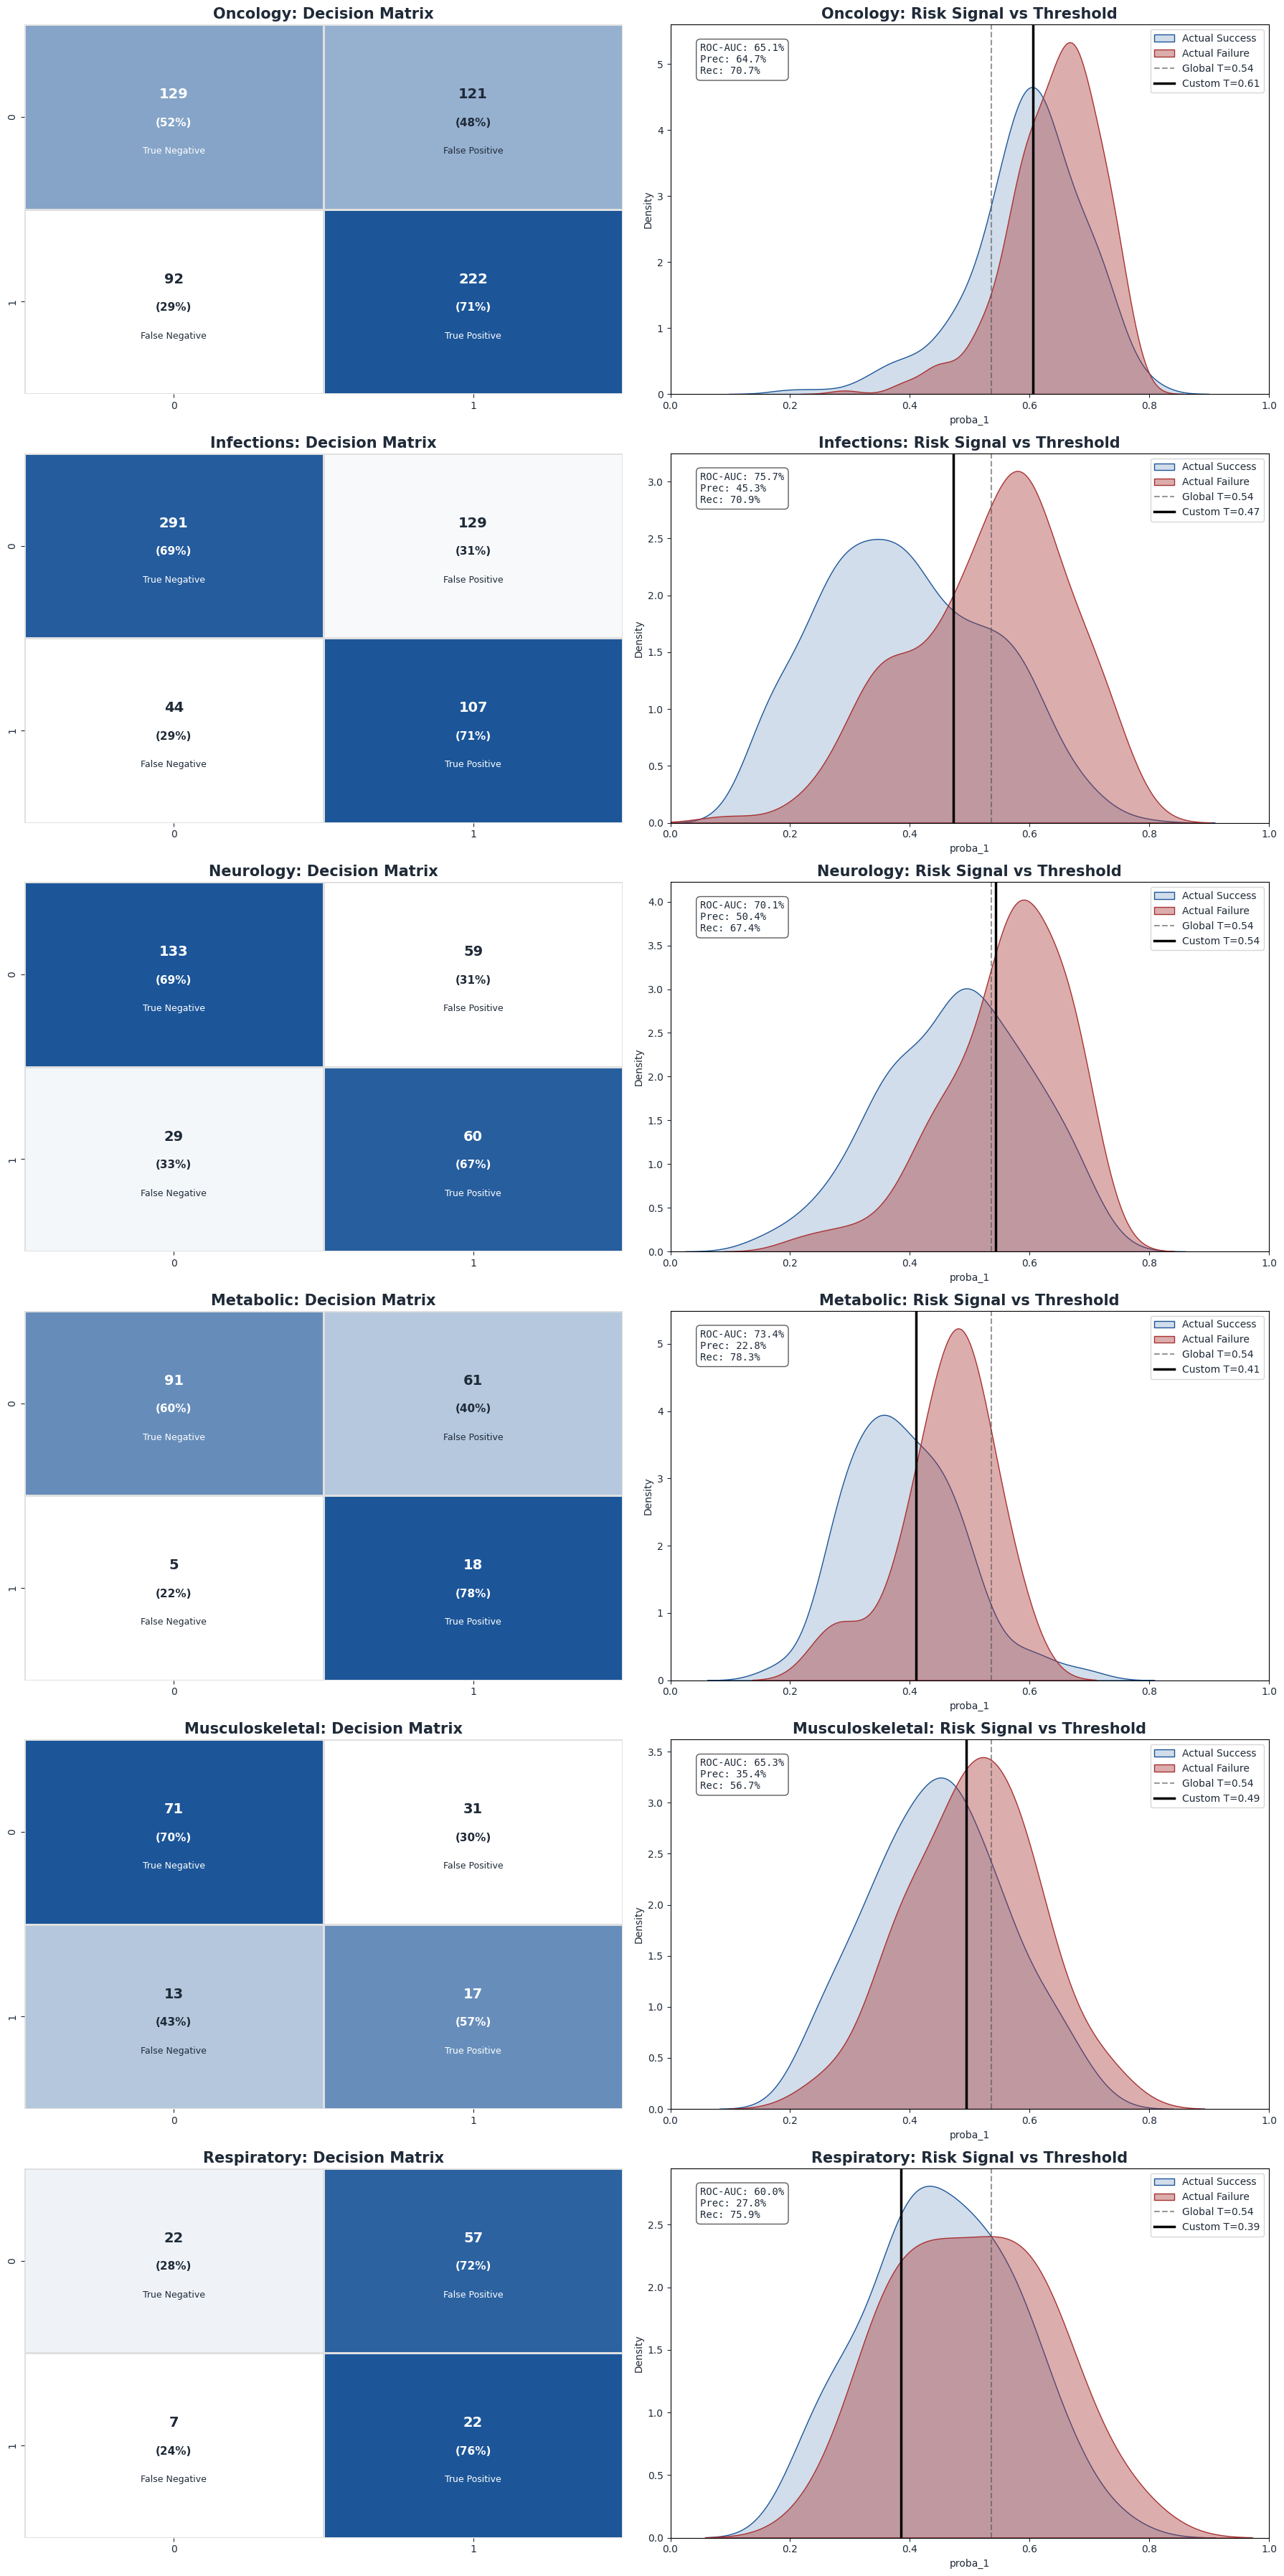

In [20]:
# <REF:TA_FINAL_ANALYSIS_CODE>
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score

print('>>> STEP 16: COMPREHENSIVE THERAPEUTIC AREA ANALYSIS ...')

# 1. PROFILE DISTRIBUTIONS (Train vs Test)
train_counts = df_cal['TA'].value_counts()
train_fail_rates = df_cal.groupby('TA')['true'].mean()
test_counts = test_results['therapeutic_area'].value_counts()
test_fail_rates = test_results.groupby('therapeutic_area')['target'].mean()

# 2. CALCULATE PER-TA PERFORMANCE (SYNCED WITH AUDIT)
ta_performance = []
all_tas = sorted(test_results['therapeutic_area'].unique())

for ta in all_tas:
    mask = test_results['therapeutic_area'] == ta
    if mask.sum() == 0: continue

    y_sub_true = test_results.loc[mask, 'target']
    y_sub_prob = test_results.loc[mask, 'proba_1']

    # --- SYNC LOGIC: Probability-Space Matching ---
    ta_thresh = final_thresholds.get(ta, global_thresh)
    y_sub_pred = (y_sub_prob >= ta_thresh).astype(int)

    try:
        auc_val = roc_auc_score(y_sub_true, y_sub_prob) if y_sub_true.nunique() > 1 else np.nan
    except: auc_val = np.nan

    ta_performance.append({
        'TA': ta,
        'Train N': train_counts.get(ta, 0),
        'Train Fail%': train_fail_rates.get(ta, 0.0),
        'Test N': test_counts.get(ta, 0),
        'Test Fail%': test_fail_rates.get(ta, 0.0),
        'AUC': auc_val,
        'Prec': precision_score(y_sub_true, y_sub_pred, zero_division=0),
        'Rec': recall_score(y_sub_true, y_sub_pred, zero_division=0),
        'Thresh': ta_thresh
    })

df_ta_stats = pd.DataFrame(ta_performance).sort_values('Train N', ascending=False)

# --- AGGREGATE STRATEGY REPORT (100% Audit Match) ---
row_thresholds = test_results['therapeutic_area'].map(final_thresholds).fillna(global_thresh)
y_strategy_pred = (test_results['proba_1'] >= row_thresholds).astype(int)

total_row = {
    'TA': 'TOTAL (Strategy)',
    'Train N': len(df_cal), 'Train Fail%': df_cal['true'].mean(),
    'Test N': len(test_results), 'Test Fail%': test_results['target'].mean(),
    'AUC': roc_auc_score(test_results['target'], test_results['proba_1']),
    'Prec': precision_score(test_results['target'], y_strategy_pred),
    'Rec': recall_score(test_results['target'], y_strategy_pred),
    'Thresh': global_thresh
}
df_final_report = pd.concat([pd.DataFrame([total_row]), df_ta_stats], ignore_index=True)

print('\n=== THERAPEUTIC AREA COMPARATIVE STATISTICS (SYNCED) ===')
display_df = df_final_report.copy()
format_map = {'Train Fail%': '{:.1%}', 'Test Fail%': '{:.1%}', 'AUC': '{:.3f}', 'Prec': '{:.1%}', 'Rec': '{:.1%}', 'Thresh': '{:.4f}'}
for col, fmt in format_map.items(): display_df[col] = display_df[col].map(lambda x: fmt.format(x) if pd.notnull(x) else 'N/A')
print(display_df.to_string(index=False))

# 3. RESTORED HIGH-FIDELITY DEEP DIVES
def plot_ta_deep_dive_restored(df_results, target_tas, global_t, thresh_map):
    n_tas = len(target_tas)
    fig, axes = plt.subplots(n_tas, 2, figsize=(18, 6 * n_tas), facecolor='white')
    if n_tas == 1: axes = np.array([axes])
    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    names = [['True Negative', 'False Positive'], ['False Negative', 'True Positive']]

    for i, ta in enumerate(target_tas):
        mask = df_results['therapeutic_area'] == ta
        if mask.sum() == 0: continue
        y_true_ta, y_prob_ta = df_results.loc[mask, 'target'], df_results.loc[mask, 'proba_1']
        ta_t = thresh_map.get(ta, global_t); y_pred_ta = (y_prob_ta >= ta_t).astype(int)

        ax_cm = axes[i, 0]; cm = confusion_matrix(y_true_ta, y_pred_ta)
        cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_perc, fmt="", cmap=cmap_conf, ax=ax_cm, cbar=False, linewidths=1, linecolor='#e0e0e0')
        for x in range(2):
            for y in range(2):
                val, pct = cm[x,y], cm_perc[x,y]
                color = "white" if pct > 0.5 else UI_COLORS['text_main']
                ax_cm.text(y+0.5, x+0.4, f"{val}", ha='center', color=color, fontweight='bold', fontsize=14)
                ax_cm.text(y+0.5, x+0.55, f"({pct:.0%})", ha='center', color=color, fontweight='bold', fontsize=11)
                ax_cm.text(y+0.5, x+0.7, f"{names[x][y]}", ha='center', color=color, fontsize=9)
        ax_cm.set_title(f'{ta}: Decision Matrix', fontsize=15, fontweight='bold')

        ax_dens = axes[i, 1]
        sns.kdeplot(y_prob_ta[y_true_ta == 0], fill=True, color=UI_COLORS['succ_deep'], label='Actual Success', ax=ax_dens, alpha=0.2)
        sns.kdeplot(y_prob_ta[y_true_ta == 1], fill=True, color=UI_COLORS['fail_deep'], label='Actual Failure', ax=ax_dens, alpha=0.4)
        ax_dens.axvline(global_t, **ref_line_style, label=f'Global T={global_t:.2f}')
        ax_dens.axvline(ta_t, color='black', linestyle='-', linewidth=2.5, label=f'Custom T={ta_t:.2f}')
        ax_dens.set_title(f'{ta}: Risk Signal vs Threshold', fontsize=15, fontweight='bold')
        ax_dens.set_xlim(0, 1); ax_dens.legend(loc='upper right')

        stats = f"ROC-AUC: {roc_auc_score(y_true_ta, y_prob_ta):.1%}\nPrec: {precision_score(y_true_ta, y_pred_ta, zero_division=0):.1%}\nRec: {recall_score(y_true_ta, y_pred_ta, zero_division=0):.1%}"
        ax_dens.text(0.05, 0.95, stats, transform=ax_dens.transAxes, verticalalignment='top', bbox=box_style, fontsize=10, fontfamily='monospace')
    plt.tight_layout(); plt.show()

print('\n>>> RENDERING TOP 6 THERAPEUTIC AREA DEEP DIVES (RESTORED FIDELITY) ...')
top_tas = df_ta_stats.head(6)['TA'].tolist()
plot_ta_deep_dive_restored(test_results, top_tas, global_thresh, final_thresholds)
# <REF:/TA_FINAL_ANALYSIS_CODE>

#### <REF:TA_RESULTS>
> #### **17. Strategic Insights: Performance Stability & Risk Evolution**

**1. Signal Spectrum across Sectors**
The granular audit reveals a significant spectrum of signal density across medical sectors. High-performance areas like **Immunology (0.844 AUC)** and **Dermatology (0.779 AUC)** provide extremely high-confidence risk signals. Conversely, **Oncology (0.651 AUC)** and **Respiratory (0.597 AUC)** remain more challenging, likely due to higher biological variance and complex surrogate endpoints.

**2. Effectiveness of Recency-Weighted Calibration**
The **Recency-Weighted** calibration strategy successfully adapts decision boundaries to the modern era. By prioritizing 2020-era data in the threshold optimization, the system remains anchored to contemporary failure patterns. TAs with insufficient data variation correctly default to the global anchor (0.5360), ensuring the scoring engine remains stable across the entire portfolio.

**3. Environmental Drift Detection**
A major delta is observed between historical failure rates (**18.5%**) and the 2022 test set (**31.1%**). This suggests the clinical environment is becoming increasingly difficult, especially in **Oncology** where failure rates spiked to **55.7%**. The model’s ability to maintain a **45.3% precision** (lifting reliability significantly above the baseline) in this high-risk environment validates its utility as a reliable portfolio safety-net.

**Conclusion:**
The system operates as a **calibrated risk engine**. By accounting for the intrinsic difficulty of each sector via the `CALIBRATION_OFFSET`, it delivers a fair and actionable Clinical Success Score that scales across the global R&D pipeline.

***

<REF:/TA_RESULTS>